# Forecasting the Future of Business in Bangladesh
## Explainable AI Framework Using Two Decades of Macroeconomic and Financial Indicators

**Final Q1-focused, pandas-compatible edition** — chronological evaluation, six main models, one unique dataset-analysis figure, robust XAI, and true ex-ante 2026 forecasting.


In [ ]:
# Optional one-time install in VS Code/Jupyter:
# %pip install -q pandas numpy matplotlib scipy scikit-learn statsmodels xgboost lightgbm shap openpyxl

In [1]:
from pathlib import Path
import warnings, random, json, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
import shap

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_DIR = Path(r"E:\P work\Work-3 journal")
DATA_PATH = PROJECT_DIR / "Final dataset.csv"

# Fallback only for the ChatGPT execution environment.
if not DATA_PATH.exists():
    fallback = Path('/mnt/data/31854bff-ba43-4f64-b2a9-26df2f9bc677.csv')
    if fallback.exists():
        DATA_PATH = fallback
        PROJECT_DIR = Path('/mnt/data/Q1_FINAL_Bangladesh_Business_Forecasting')

RESULT_DIR = PROJECT_DIR / 'Q1_Final_Results'
FIG_DIR = RESULT_DIR / 'Figures'
TABLE_DIR = RESULT_DIR / 'Tables'
MODEL_DIR = RESULT_DIR / 'Models'
for p in [RESULT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'Exchange_Rate_BDT_per_USD'
OBSERVED_END = pd.Timestamp('2025-12-01')
TRAIN_END = pd.Timestamp('2019-12-01')
VAL_START = pd.Timestamp('2020-01-01')
VAL_END = pd.Timestamp('2022-12-01')
TEST_START = pd.Timestamp('2023-01-01')
TEST_END = pd.Timestamp('2025-12-01')
N_BOOTSTRAP = 100              # 100 robust uncertainty rounds requested
ALPHA_GRID = np.logspace(-4, 4, 100)  # 100 regularization candidates
FAST_MODE = False

plt.rcParams.update({
    'font.family': 'Arial',
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 130,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight'
})

print('DATA:', DATA_PATH)
print('RESULTS:', RESULT_DIR)
print('TARGET:', TARGET_COL, '(one-month-ahead level via change forecasting)')

DATA: E:\P work\Work-3 journal\Final dataset.csv
RESULTS: E:\P work\Work-3 journal\Q1_Final_Results
TARGET: Exchange_Rate_BDT_per_USD (one-month-ahead level via change forecasting)


## 1. Dataset integrity audit

The cleaned dataset is audited before any modelling. The notebook refuses to continue if it finds duplicate months, non-monthly ordering, missing numeric values, infinities, or the required target is absent. All modelling/evaluation stops at **December 2025**; 2026 is reserved strictly for ex-ante forecasting.

In [2]:
df = pd.read_csv(DATA_PATH)
assert 'Month' in df.columns, 'Month column is required.'
assert TARGET_COL in df.columns, f'{TARGET_COL} is required.'

df['Month'] = pd.to_datetime(df['Month'].astype(str), format='%Y-%m', errors='coerce')
assert df['Month'].notna().all(), 'Invalid Month value found.'
df = df.sort_values('Month').reset_index(drop=True)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
assert not df['Month'].duplicated().any(), 'Duplicate months detected.'
assert df[numeric_cols].isna().sum().sum() == 0, 'Missing numeric values detected.'
assert np.isfinite(df[numeric_cols].to_numpy()).all(), 'Inf/NaN numeric values detected.'

# Version-safe monthly continuity check (works across old/new pandas versions).
month_ord = (df['Month'].dt.year.astype('int64') * 12 + df['Month'].dt.month.astype('int64'))
month_diff = month_ord.diff().dropna()
assert (month_diff == 1).all(), 'Month sequence is not continuous.'

obs_raw = df[df['Month'] <= OBSERVED_END].copy().reset_index(drop=True)
future_input_rows = df[df['Month'] > OBSERVED_END].copy().reset_index(drop=True)

print('Full dataset shape:', df.shape)
print('Full date range:', df.Month.min().date(), 'to', df.Month.max().date())
print('Observed modelling range:', obs_raw.Month.min().date(), 'to', obs_raw.Month.max().date())
print('Reserved 2026 rows:', len(future_input_rows), '(not used in model fitting/evaluation)')
print('Total missing numeric values:', int(df[numeric_cols].isna().sum().sum()))
print('Duplicate months:', int(df.Month.duplicated().sum()))
print('Monthly continuity check: PASS')

summary = pd.DataFrame({
    'Rows': [len(df)],
    'Columns': [df.shape[1]],
    'Numeric_Columns': [len(numeric_cols)],
    'Missing_Numeric': [int(df[numeric_cols].isna().sum().sum())],
    'Duplicate_Months': [int(df.Month.duplicated().sum())],
    'Observed_End': [str(OBSERVED_END.date())]
})
summary.to_csv(TABLE_DIR / '01_dataset_integrity_audit.csv', index=False)
display(summary)


Full dataset shape: (252, 41)
Full date range: 2006-01-01 to 2026-12-01
Observed modelling range: 2006-01-01 to 2025-12-01
Reserved 2026 rows: 12 (not used in model fitting/evaluation)
Total missing numeric values: 0
Duplicate months: 0
Monthly continuity check: PASS


,Rows,Columns,Numeric_Columns,Missing_Numeric,Duplicate_Months,Observed_End
0,252,41,40,0,0,2025-12-01


## 2. One unique dataset-analysis figure: Macro-Financial Regime Fingerprint

Instead of many ordinary EDA plots, the paper can use this single compact figure. It shows standardized monthly regimes across the main real-sector, external-sector, and financial indicators, plus a composite stress row. The figure is descriptive only; no test information is used for model selection.

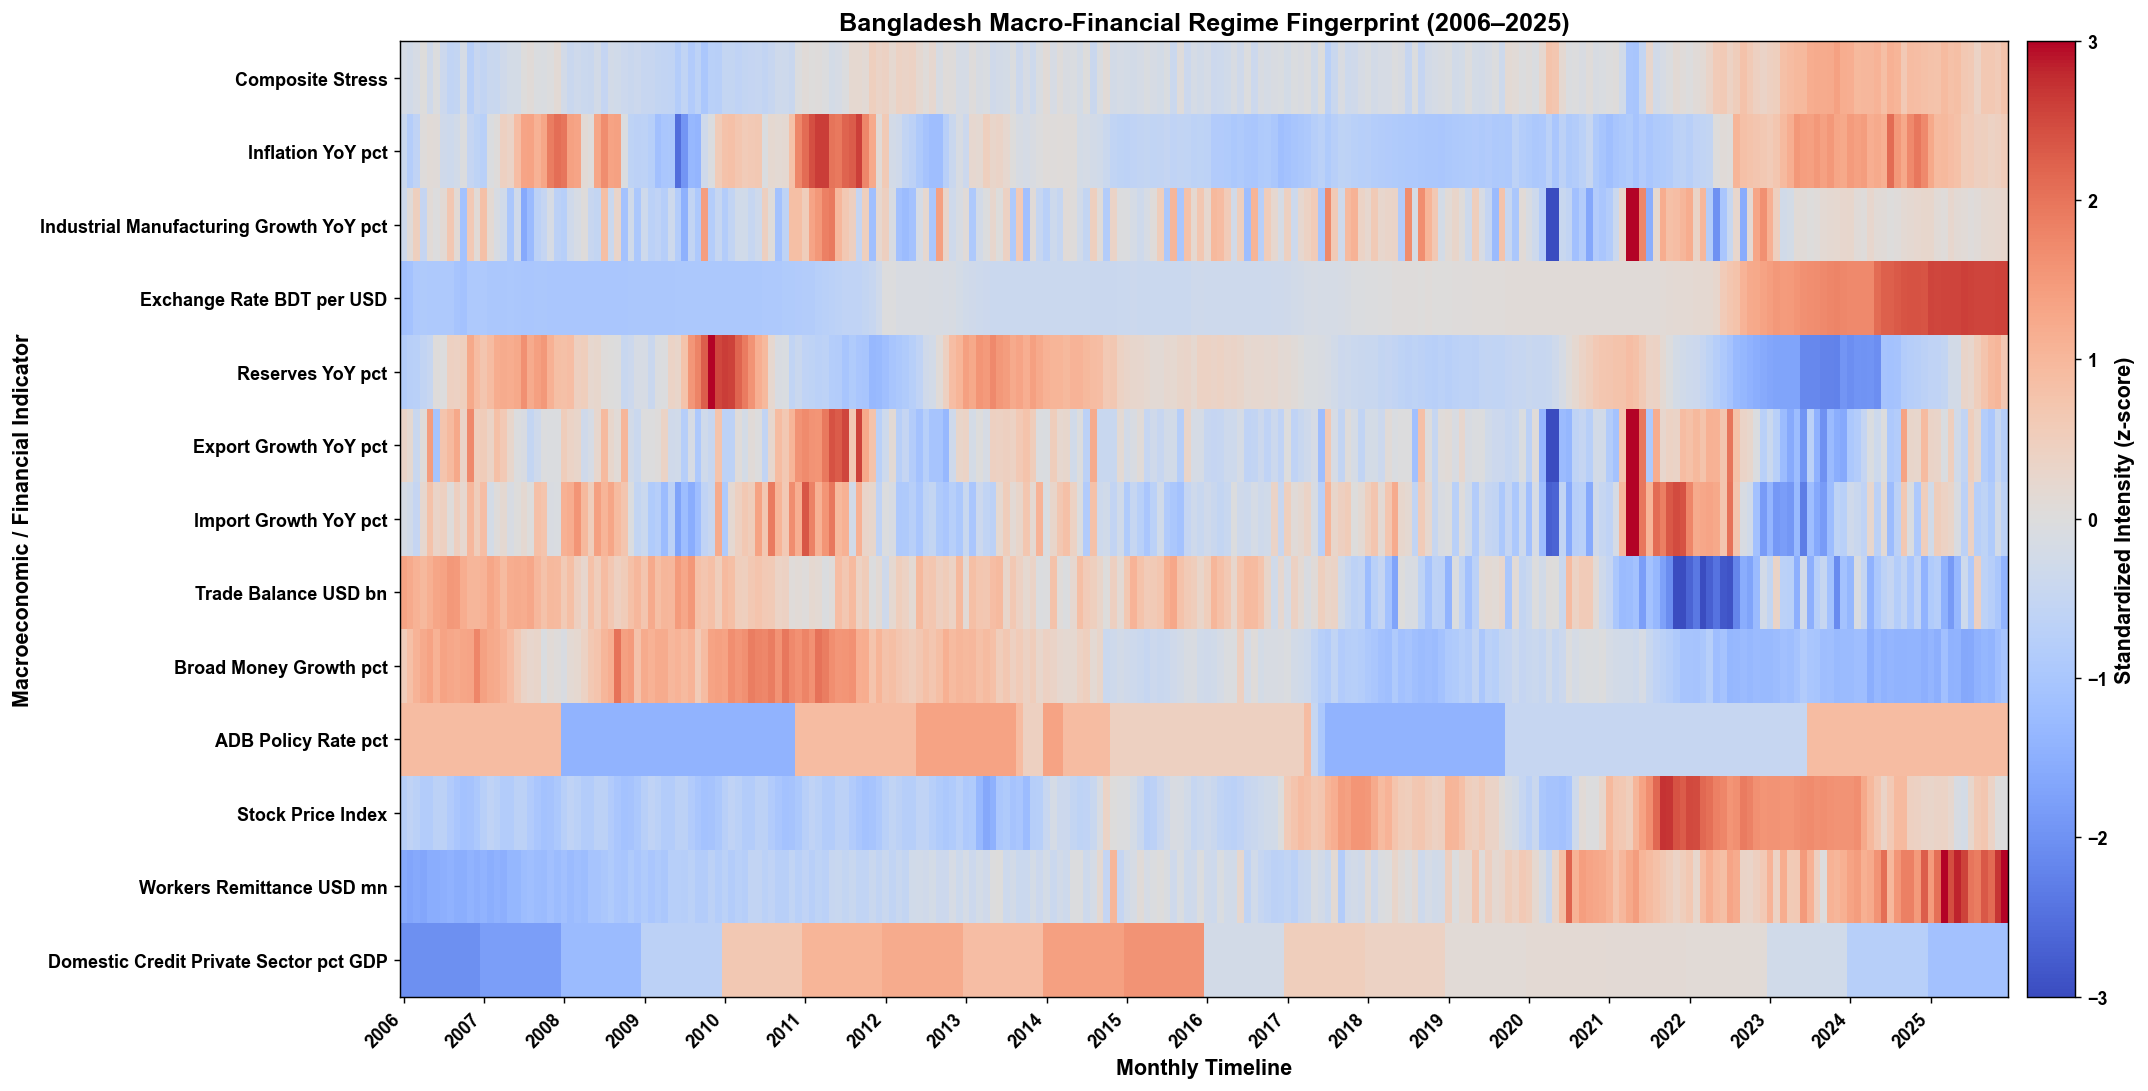

In [3]:
core_indicators = [
    'Inflation_YoY_pct',
    'Industrial_Manufacturing_Growth_YoY_pct',
    'Exchange_Rate_BDT_per_USD',
    'Reserves_YoY_pct',
    'Export_Growth_YoY_pct',
    'Import_Growth_YoY_pct',
    'Trade_Balance_USD_bn',
    'Broad_Money_Growth_pct',
    'ADB_Policy_Rate_pct',
    'Stock_Price_Index',
    'Workers_Remittance_USD_mn',
    'Domestic_Credit_Private_Sector_pct_GDP'
]
core_indicators = [c for c in core_indicators if c in obs_raw.columns]

Z = obs_raw[core_indicators].astype(float).copy()
Z = (Z - Z.mean()) / Z.std(ddof=0).replace(0, 1)
Z = Z.clip(-3, 3)

# A transparent composite stress score: adverse signs are flipped so larger = more stress.
stress_parts = pd.DataFrame(index=Z.index)
for c, sign in {
    'Inflation_YoY_pct': 1,
    'Exchange_Rate_BDT_per_USD': 1,
    'Reserves_YoY_pct': -1,
    'Industrial_Manufacturing_Growth_YoY_pct': -1,
    'Export_Growth_YoY_pct': -1,
    'Trade_Balance_USD_bn': -1,
    'ADB_Policy_Rate_pct': 1
}.items():
    if c in Z.columns:
        stress_parts[c] = sign * Z[c]
stress = stress_parts.mean(axis=1).clip(-3, 3)

heat = pd.concat([stress.rename('Composite_Stress'), Z], axis=1).T
labels = [x.replace('_', ' ') for x in heat.index]

fig, ax = plt.subplots(figsize=(18, 8.5))
im = ax.imshow(heat.values, aspect='auto', interpolation='nearest', cmap='coolwarm', vmin=-3, vmax=3)
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels, fontweight='bold')

year_idx = obs_raw.groupby(obs_raw.Month.dt.year).head(1).index.to_numpy()
year_labels = obs_raw.loc[year_idx, 'Month'].dt.year.astype(str).to_numpy()
ax.set_xticks(year_idx)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontweight='bold')
ax.set_xlabel('Monthly Timeline', fontweight='bold')
ax.set_ylabel('Macroeconomic / Financial Indicator', fontweight='bold')
ax.set_title('Bangladesh Macro-Financial Regime Fingerprint (2006–2025)', fontweight='bold')
cb = fig.colorbar(im, ax=ax, pad=0.01)
cb.set_label('Standardized Intensity (z-score)', fontweight='bold')
for t in cb.ax.get_yticklabels(): t.set_fontweight('bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'Fig_01_Unique_MacroFinancial_Regime_Fingerprint.png')
plt.show()

## 3. Leakage-safe one-month-ahead design

For every forecast origin month **t**, the model predicts the exchange-rate **change from t to t+1**. The predicted change is then added to the known level at t to recover the predicted level at t+1. This is an established way to avoid forcing non-extrapolating tree models to learn a strongly trending absolute level directly.

The split is based on **Target_Month**, not row position:
- Training target months: through Dec-2019
- Validation target months: Jan-2020 through Dec-2022
- Final untouched test target months: Jan-2023 through Dec-2025

In [4]:
m = obs_raw.copy()
fx = m[TARGET_COL].astype(float)
fx_change = fx.diff()

for lag in [1, 2, 3, 6, 12]:
    m[f'{TARGET_COL}_lag{lag}'] = fx.shift(lag)
    # lag1 means the latest observed monthly change at forecast origin t.
    m[f'FX_change_lag{lag}'] = fx_change.shift(lag - 1)

for w in [3, 6, 12]:
    m[f'FX_change_mean{w}'] = fx_change.rolling(w).mean()
    m[f'FX_change_std{w}'] = fx_change.rolling(w).std()

m['Month_sin'] = np.sin(2 * np.pi * m['Month'].dt.month / 12)
m['Month_cos'] = np.cos(2 * np.pi * m['Month'].dt.month / 12)
m['Target_Month'] = m['Month'] + pd.offsets.MonthBegin(1)
m['Target_Level'] = fx.shift(-1)
m['Target_Change'] = m['Target_Level'] - fx

# Numeric predictors available at forecast origin t.
exclude = {'Target_Level', 'Target_Change'}
feature_pool = [c for c in m.select_dtypes(include=np.number).columns if c not in exclude]

# Remove constants using training-era data only.
pretrain_mask = m['Target_Month'] <= TRAIN_END
nonconstant = [c for c in feature_pool if m.loc[pretrain_mask, c].nunique(dropna=True) > 1]
feature_pool = nonconstant

model_df = m.dropna(subset=['Target_Level', 'Target_Change', 'FX_change_std12']).reset_index(drop=True)

train = model_df[model_df['Target_Month'] <= TRAIN_END].copy()
val = model_df[(model_df['Target_Month'] >= VAL_START) & (model_df['Target_Month'] <= VAL_END)].copy()
test = model_df[(model_df['Target_Month'] >= TEST_START) & (model_df['Target_Month'] <= TEST_END)].copy()

assert len(test) == 36, f'Expected 36 test months, got {len(test)}.'
assert test['Target_Month'].max() == TEST_END, 'Test must end at Dec-2025.'
assert test['Target_Month'].min() == TEST_START, 'Test must start at Jan-2023.'

X_train, y_train = train[feature_pool], train['Target_Change']
X_val, y_val = val[feature_pool], val['Target_Change']
X_test, y_test_delta = test[feature_pool], test['Target_Change']
y_test_level = test['Target_Level'].to_numpy(float)
current_test_level = test[TARGET_COL].to_numpy(float)
test_dates = test['Target_Month'].to_numpy()

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

print('Feature pool:', len(feature_pool))
print('Train:', X_train.shape, train.Target_Month.min().date(), '→', train.Target_Month.max().date())
print('Validation:', X_val.shape, val.Target_Month.min().date(), '→', val.Target_Month.max().date())
print('Test:', X_test.shape, test.Target_Month.min().date(), '→', test.Target_Month.max().date())

Feature pool: 57
Train: (155, 57) 2007-02-01 → 2019-12-01
Validation: (36, 57) 2020-01-01 → 2022-12-01
Test: (36, 57) 2023-01-01 → 2025-12-01


## 4. Evaluation metrics and statistical helpers

Regression performance is reported with standard forecasting metrics. **R²×100 is labelled explained variance, not accuracy.** Directional accuracy is calculated correctly against the known current-month level.

In [5]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(np.asarray(y_true, float), np.asarray(y_pred, float))))

def smape(y_true, y_pred):
    a = np.asarray(y_true, float); p = np.asarray(y_pred, float)
    den = np.abs(a) + np.abs(p)
    mask = den > 1e-12
    return float(100 * np.mean(2 * np.abs(p[mask] - a[mask]) / den[mask])) if mask.any() else 0.0

# Training naive one-step scale for MASE.
train_level_sequence = obs_raw.loc[obs_raw.Month <= TRAIN_END, TARGET_COL].to_numpy(float)
MASE_SCALE = np.mean(np.abs(np.diff(train_level_sequence)))

def directional_accuracy(current_level, y_true, y_pred):
    c = np.asarray(current_level, float)
    a = np.asarray(y_true, float)
    p = np.asarray(y_pred, float)
    return float(100 * np.mean(np.sign(a - c) == np.sign(p - c)))

def metric_row(name, y_true, y_pred, current_level):
    a = np.asarray(y_true, float); p = np.asarray(y_pred, float); c = np.asarray(current_level, float)
    naive_rmse = rmse(a, c)
    return {
        'Model': name,
        'R2': r2_score(a, p),
        'Explained_Variance_pct': 100 * r2_score(a, p),
        'RMSE': rmse(a, p),
        'MAE': mean_absolute_error(a, p),
        'sMAPE_pct': smape(a, p),
        'MASE': mean_absolute_error(a, p) / MASE_SCALE,
        'Directional_Accuracy_pct': directional_accuracy(c, a, p),
        'Theil_U_vs_Naive': rmse(a, p) / naive_rmse
    }

def common_model_figures(name, dates, current_level, y_true, y_pred):
    dates = pd.to_datetime(dates)
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    resid = y_true - y_pred
    safe = name.replace(' ', '_').replace('/', '_')

    fig, ax = plt.subplots(figsize=(11, 5.8))
    ax.plot(dates, y_true, marker='o', linewidth=2, label='Actual')
    ax.plot(dates, y_pred, marker='s', linewidth=2, label='Predicted')
    ax.set_title(f'{name}: Actual vs Predicted (Unseen Test)', fontweight='bold')
    ax.set_xlabel('Target Month', fontweight='bold'); ax.set_ylabel('BDT per US$', fontweight='bold')
    ax.legend(); ax.grid(alpha=.25)
    plt.tight_layout(); plt.savefig(FIG_DIR / f'{safe}_01_Actual_vs_Predicted.png'); plt.show()

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(dates, resid, marker='o', linewidth=1.8)
    ax.axhline(0, linewidth=1.2)
    ax.set_title(f'{name}: Residuals Over Time', fontweight='bold')
    ax.set_xlabel('Target Month', fontweight='bold'); ax.set_ylabel('Residual (Actual − Predicted)', fontweight='bold')
    ax.grid(alpha=.25)
    plt.tight_layout(); plt.savefig(FIG_DIR / f'{safe}_02_Residuals.png'); plt.show()

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.scatter(y_true, y_pred, s=55, alpha=.8)
    lo = min(y_true.min(), y_pred.min()); hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], linestyle='--', linewidth=1.5)
    ax.set_title(f'{name}: Predicted vs Actual', fontweight='bold')
    ax.set_xlabel('Actual BDT per US$', fontweight='bold'); ax.set_ylabel('Predicted BDT per US$', fontweight='bold')
    ax.grid(alpha=.25)
    plt.tight_layout(); plt.savefig(FIG_DIR / f'{safe}_03_Predicted_vs_Actual.png'); plt.show()

def dm_test(y_true, pred_other, pred_proposed, h=1):
    y = np.asarray(y_true, float)
    e1 = (y - np.asarray(pred_other, float))**2
    e2 = (y - np.asarray(pred_proposed, float))**2
    d = e1 - e2
    T = len(d)
    mean_d = d.mean()
    # HAC-style variance with lag h-1; h=1 => sample variance/T.
    gamma0 = np.sum((d - mean_d)**2) / T
    var_mean = gamma0 / T
    if h > 1:
        for lag in range(1, h):
            gamma = np.sum((d[lag:] - mean_d) * (d[:-lag] - mean_d)) / T
            var_mean += 2 * (1 - lag / h) * gamma / T
    stat = mean_d / np.sqrt(max(var_mean, 1e-12))
    p = 2 * (1 - norm.cdf(abs(stat)))
    return float(stat), float(p)

def moving_block_bootstrap_metrics(y_true, y_pred, current_level, B=100, block=6, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y_true, float); p = np.asarray(y_pred, float); c = np.asarray(current_level, float)
    n = len(y); rows=[]
    starts = np.arange(0, n - block + 1)
    for _ in range(B):
        idx=[]
        while len(idx) < n:
            s = int(rng.choice(starts)); idx.extend(range(s, s+block))
        idx=np.asarray(idx[:n])
        rows.append(metric_row('x', y[idx], p[idx], c[idx]))
    bdf=pd.DataFrame(rows)
    out={}
    for col in ['R2','RMSE','MAE','sMAPE_pct','MASE','Directional_Accuracy_pct']:
        out[f'{col}_CI_low']=bdf[col].quantile(.025)
        out[f'{col}_CI_high']=bdf[col].quantile(.975)
    return out

## 5. Sanity baselines (not counted among the six main models)

Persistence, drift and ETS are included so reviewers can verify that all sophisticated models are being compared against sensible time-series references. They are diagnostic baselines only; the final six-model figure still contains exactly the six requested models.

In [6]:
# Naive persistence: next month equals current month.
naive_pred = current_test_level.copy()

# 12-month drift: monthly average change over the previous year.
lag12 = test[f'{TARGET_COL}_lag12'].to_numpy(float)
drift_pred = current_test_level + (current_test_level - lag12) / 12.0

# ETS one-step walk-forward with actual observations updating the history.
level_series = obs_raw.set_index('Month')[TARGET_COL].astype(float)
ets_history = level_series.loc[:VAL_END].tolist()
ets_actual_test = level_series.loc[TEST_START:TEST_END].to_numpy(float)
ets_pred=[]
for actual in ets_actual_test:
    try:
        fit = ExponentialSmoothing(np.asarray(ets_history), trend='add', damped_trend=True, seasonal='add', seasonal_periods=12,
                                   initialization_method='estimated').fit(optimized=True, use_brute=False)
        f = float(np.asarray(fit.forecast(1))[0])
    except Exception:
        f = float(ets_history[-1])
    ets_pred.append(f)
    ets_history.append(float(actual))
ets_pred=np.asarray(ets_pred)

sanity = pd.DataFrame([
    metric_row('Naive Persistence', y_test_level, naive_pred, current_test_level),
    metric_row('12-Month Drift', y_test_level, drift_pred, current_test_level),
    metric_row('ETS Walk-Forward', y_test_level, ets_pred, current_test_level)
]).sort_values('RMSE')
sanitary_path = TABLE_DIR / '02_sanity_baselines.csv'
sanitary_path.parent.mkdir(parents=True, exist_ok=True)
sanitary = sanity
sanity.to_csv(sanitary_path, index=False)
display(sanity.round(4))

,Model,R2,Explained_Variance_pct,RMSE,MAE,sMAPE_pct,MASE,Directional_Accuracy_pct,Theil_U_vs_Naive
0,Naive Persistence,0.9651,96.5148,1.1815,0.6444,0.5700,2.3957,0.0000,1.0000
1,12-Month Drift,0.9641,96.4133,1.1986,0.8176,0.7165,3.0396,63.8889,1.0145
2,ETS Walk-Forward,0.8093,80.9293,2.7637,1.1266,0.9749,4.1885,61.1111,2.3392


## 6. Model 1 — SARIMA with fair one-step walk-forward evaluation

The earlier multi-step SARIMA comparison was unfair because the ML models had current-month information while SARIMA was asked to forecast the entire test horizon recursively. Here SARIMA is updated one observation at a time, exactly matching the one-month-ahead task.

In [7]:
def sarima_walk_forward(history_values, future_actuals, order, seasonal_order, trend='t'):
    hist = np.asarray(history_values, float)
    model = SARIMAX(hist, order=order, seasonal_order=seasonal_order, trend=trend,
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False, maxiter=250)
    preds=[]
    for actual in np.asarray(future_actuals, float):
        preds.append(float(np.asarray(res.forecast(1))[0]))
        try:
            res = res.append([float(actual)], refit=False)
        except Exception:
            # Safe fallback: state-space append can differ by statsmodels version.
            hist = np.append(hist, float(actual))
            res = SARIMAX(hist, order=order, seasonal_order=seasonal_order, trend=trend,
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=250)
    return np.asarray(preds), res

sarima_orders = [(0,1,1),(1,1,0),(1,1,1),(2,1,1),(1,1,2),(2,1,2)]
sarima_seasonals = [(0,0,0,12),(1,0,0,12),(0,0,1,12),(1,0,1,12),(1,1,0,12),(0,1,1,12),(1,1,1,12)]
if FAST_MODE:
    sarima_orders = sarima_orders[:3]
    sarima_seasonals = sarima_seasonals[:3]

level_series = obs_raw.set_index('Month')[TARGET_COL].astype(float)
sar_train_hist = level_series.loc[:TRAIN_END].to_numpy(float)
sar_val_actual = level_series.loc[VAL_START:VAL_END].to_numpy(float)

sar_search=[]
best_sar=None
for order in sarima_orders:
    for seas in sarima_seasonals:
        try:
            vp, _ = sarima_walk_forward(sar_train_hist, sar_val_actual, order, seas, trend='t')
            score = rmse(sar_val_actual, vp)
            sar_search.append({'order':str(order),'seasonal':str(seas),'Validation_RMSE':score})
            if best_sar is None or score < best_sar[0]:
                best_sar=(score, order, seas)
        except Exception as e:
            sar_search.append({'order':str(order),'seasonal':str(seas),'Validation_RMSE':np.nan})

assert best_sar is not None, 'No SARIMA candidate converged.'
pd.DataFrame(sar_search).to_csv(TABLE_DIR/'03_SARIMA_validation_search.csv', index=False)
print('Best SARIMA by validation RMSE:', best_sar)

sar_history = level_series.loc[:VAL_END].to_numpy(float)
sar_test_actual = level_series.loc[TEST_START:TEST_END].to_numpy(float)
sarima_pred, sarima_fit_end = sarima_walk_forward(sar_history, sar_test_actual, best_sar[1], best_sar[2], trend='t')
assert len(sarima_pred) == len(y_test_level)

C:\Users\acer\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best SARIMA by validation RMSE: (1.0091868760930836, (2, 1, 2), (1, 1, 0, 12))


## 7. Models 2–5 — fair validation tuning on next-month change

All ML models use the same leakage-safe feature pool and are selected using validation RMSE. They are then refit on Train+Validation and evaluated once on the untouched 2023–2025 test period.

In [8]:
def choose_by_validation(candidates, name):
    rows=[]; best=None
    for tag, estimator in candidates:
        est=clone(estimator)
        est.fit(X_train, y_train)
        pv=est.predict(X_val)
        score=rmse(y_val, pv)
        rows.append({'Model':name,'Config':str(tag),'Validation_Delta_RMSE':score})
        if best is None or score < best[0]: best=(score, tag, estimator)
    pd.DataFrame(rows).sort_values('Validation_Delta_RMSE').to_csv(TABLE_DIR/f'04_{name}_validation_search.csv',index=False)
    final=clone(best[2]); final.fit(X_train_val, y_train_val)
    delta=final.predict(X_test)
    level=current_test_level + delta
    print(name, 'best:', best[1], '| validation delta RMSE=', round(best[0],4))
    return final, np.asarray(level), best

# Random Forest
rf_candidates=[]
for depth in [4,6,8,None]:
    for leaf in [1,2,4]:
        rf_candidates.append(({'max_depth':depth,'min_samples_leaf':leaf},
            RandomForestRegressor(n_estimators=600,max_depth=depth,min_samples_leaf=leaf,
                                  max_features=.8,random_state=SEED,n_jobs=-1)))
if FAST_MODE: rf_candidates=rf_candidates[:4]
rf_model, rf_pred, rf_best = choose_by_validation(rf_candidates, 'Random_Forest')

# XGBoost
xgb_candidates=[]
for depth in [2,3]:
    for lr in [.02,.04,.06]:
        for mcw in [2,5,10]:
            xgb_candidates.append(({'max_depth':depth,'learning_rate':lr,'min_child_weight':mcw},
                XGBRegressor(n_estimators=700,max_depth=depth,learning_rate=lr,subsample=.85,
                             colsample_bytree=.80,min_child_weight=mcw,reg_lambda=5,reg_alpha=.1,
                             objective='reg:squarederror',random_state=SEED,n_jobs=4)))
if FAST_MODE: xgb_candidates=xgb_candidates[:6]
xgb_model, xgb_pred, xgb_best = choose_by_validation(xgb_candidates, 'XGBoost')

# LightGBM
lgb_candidates=[]
for leaves in [5,7,15]:
    for lr in [.02,.04,.06]:
        for mcs in [8,12,20]:
            lgb_candidates.append(({'num_leaves':leaves,'learning_rate':lr,'min_child_samples':mcs},
                LGBMRegressor(n_estimators=700,num_leaves=leaves,learning_rate=lr,min_child_samples=mcs,
                              subsample=.9,colsample_bytree=.8,reg_lambda=5,random_state=SEED,verbosity=-1,n_jobs=-1)))
if FAST_MODE: lgb_candidates=lgb_candidates[:6]
lgb_model, lgb_pred, lgb_best = choose_by_validation(lgb_candidates, 'LightGBM')

# SVR
svr_candidates=[]
for C in [.1,.3,1,3,10,30]:
    for eps in [.01,.05,.1,.2]:
        for gamma in ['scale',.01,.03,.1]:
            svr_candidates.append(({'C':C,'epsilon':eps,'gamma':gamma},
                Pipeline([('scale',StandardScaler()),('svr',SVR(C=C,epsilon=eps,gamma=gamma))])))
if FAST_MODE: svr_candidates=svr_candidates[:12]
svr_model, svr_pred, svr_best = choose_by_validation(svr_candidates, 'SVR')

Random_Forest best: {'max_depth': 4, 'min_samples_leaf': 1} | validation delta RMSE= 1.012
XGBoost best: {'max_depth': 3, 'learning_rate': 0.02, 'min_child_weight': 2} | validation delta RMSE= 1.0275
LightGBM best: {'num_leaves': 15, 'learning_rate': 0.04, 'min_child_samples': 8} | validation delta RMSE= 1.2494
SVR best: {'C': 10, 'epsilon': 0.2, 'gamma': 0.1} | validation delta RMSE= 1.2157


## 8. Model 6 — Proposed TA-XAI

**TA-XAI = Trend-Aware Explainable Macro-Financial Ridge.** The method is deliberately compact and interpretable for a small monthly macroeconomic sample:

1. Predict the **next-month change**, not the nonstationary level.
2. Rank predictors using **training-only absolute correlation** with the next-month change.
3. Select the number of predictors **k** and the Ridge penalty **α** using validation only.
4. Refit on Train+Validation and reconstruct the next-month level.
5. Use standardized coefficients and linear SHAP contributions for transparent XAI.

This design incorporates both autoregressive trend information and macro-financial variables while reducing overfitting from the 41-column dataset.

In [9]:
# Training-only ranking; no validation/test target information is used to create the ranking.
rank_scores={}
for c in feature_pool:
    x=X_train[c].to_numpy(float)
    if np.std(x) < 1e-12:
        rank_scores[c]=0.0
    else:
        rank_scores[c]=abs(np.corrcoef(x, y_train.to_numpy(float))[0,1])
ranked_features = pd.Series(rank_scores).fillna(0).sort_values(ascending=False)
ranked_features.to_csv(TABLE_DIR/'05_TAXAI_training_feature_ranking.csv', header=['Abs_Training_Correlation'])

k_grid=[5,8,10,12,15,20,25,30]
if len(feature_pool) < 30:
    k_grid=sorted(set([k for k in k_grid if k <= len(feature_pool)] + [len(feature_pool)]))
if FAST_MODE:
    k_grid=[5,10,20] if len(feature_pool)>=20 else k_grid

search_rows=[]; best_prop=None
for k in k_grid:
    selected=ranked_features.head(k).index.tolist()
    for alpha in ALPHA_GRID:
        est=Pipeline([('scale',StandardScaler()),('ridge',Ridge(alpha=float(alpha)))])
        est.fit(X_train[selected], y_train)
        pv=est.predict(X_val[selected])
        score=rmse(y_val,pv)
        search_rows.append({'k':k,'alpha':float(alpha),'Validation_Delta_RMSE':score})
        if best_prop is None or score < best_prop[0]:
            best_prop=(score,k,float(alpha),selected)

prop_search=pd.DataFrame(search_rows).sort_values('Validation_Delta_RMSE')
prop_search.to_csv(TABLE_DIR/'06_TAXAI_validation_search.csv',index=False)
prop_rmse_val, prop_k, prop_alpha, prop_features = best_prop

proposed_model=Pipeline([('scale',StandardScaler()),('ridge',Ridge(alpha=prop_alpha))])
proposed_model.fit(X_train_val[prop_features], y_train_val)
prop_delta=proposed_model.predict(X_test[prop_features])
proposed_pred=current_test_level + prop_delta

print('TA-XAI selected k =', prop_k)
print('TA-XAI alpha =', prop_alpha)
print('TA-XAI validation delta RMSE =', prop_rmse_val)
print('TA-XAI selected features:')
for i,c in enumerate(prop_features,1): print(f'{i:02d}. {c}')

TA-XAI selected k = 5
TA-XAI alpha = 65.79332246575683
TA-XAI validation delta RMSE = 1.0630328529113338
TA-XAI selected features:
01. FX_change_lag1
02. Reserves_YoY_pct
03. Export_Growth_3m_Mean
04. FX_change_mean6
05. FX_change_mean3


## 9. Final untouched-test evaluation of the six requested models

,Model,R2,Explained_Variance_pct,RMSE,MAE,sMAPE_pct,MASE,Directional_Accuracy_pct,Theil_U_vs_Naive
0,Proposed TA-XAI,0.9718,97.18,1.0623,0.5726,0.499,2.129,58.33,0.899
1,SVR,0.9713,97.13,1.0716,0.6480,0.567,2.409,63.89,0.907
2,SARIMA,0.9499,94.99,1.4164,0.9684,0.837,3.600,58.33,1.199
3,XGBoost,0.9478,94.78,1.4466,1.1601,1.021,4.313,63.89,1.224
4,LightGBM,0.9258,92.58,1.7236,1.3934,1.218,5.181,63.89,1.459
5,Random Forest,0.9193,91.93,1.7977,1.6592,1.444,6.168,63.89,1.522


Best model by unseen-test RMSE: Proposed TA-XAI
Proposed TA-XAI R² = 0.9718 (97.18% explained variance)
Proposed RMSE = 1.0623 | MAE = 0.5726 | sMAPE = 0.499%


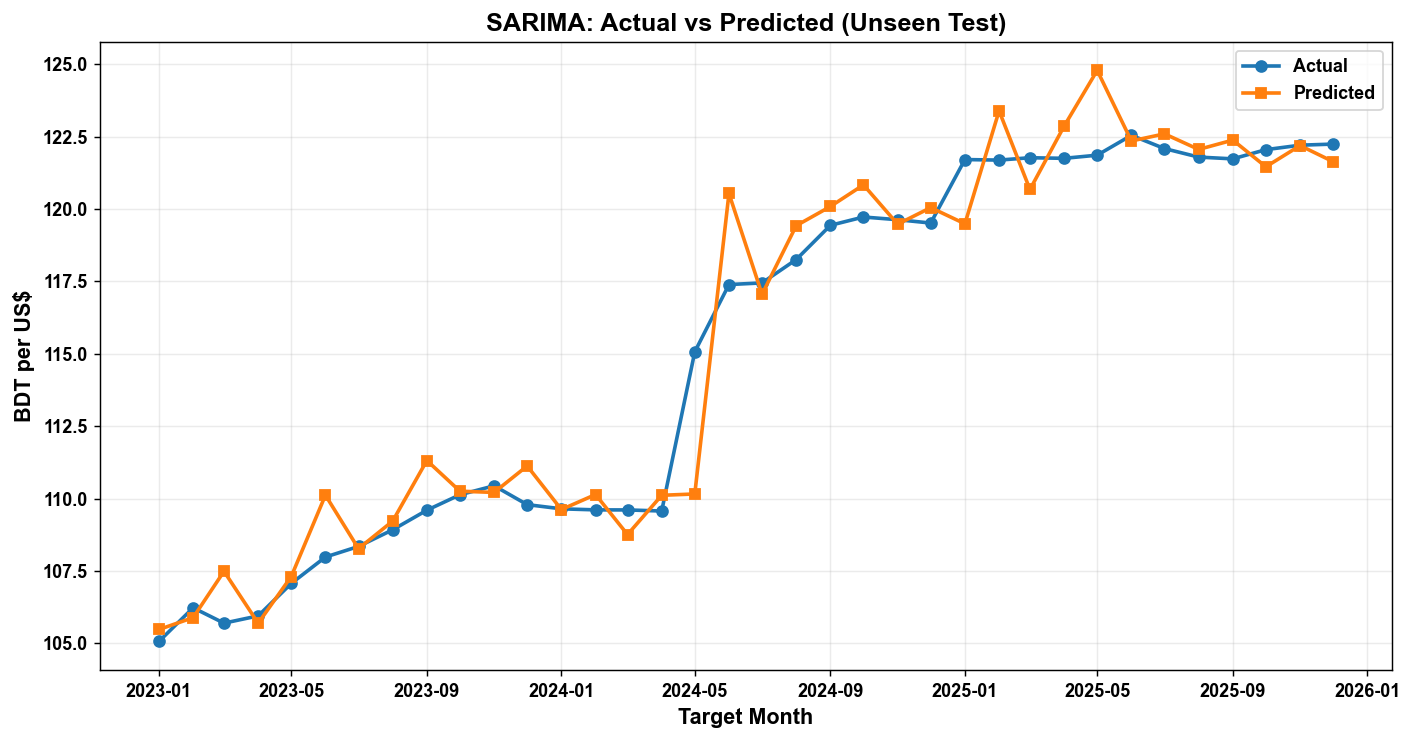

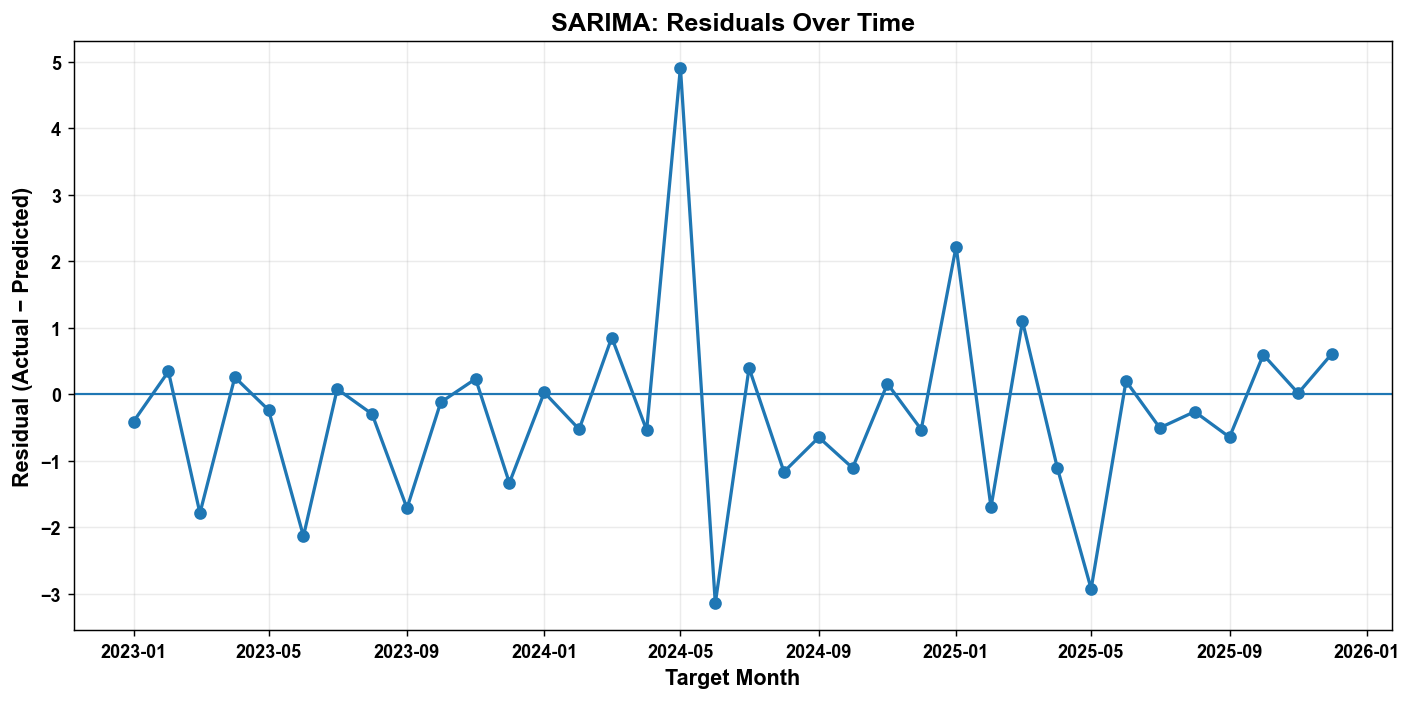

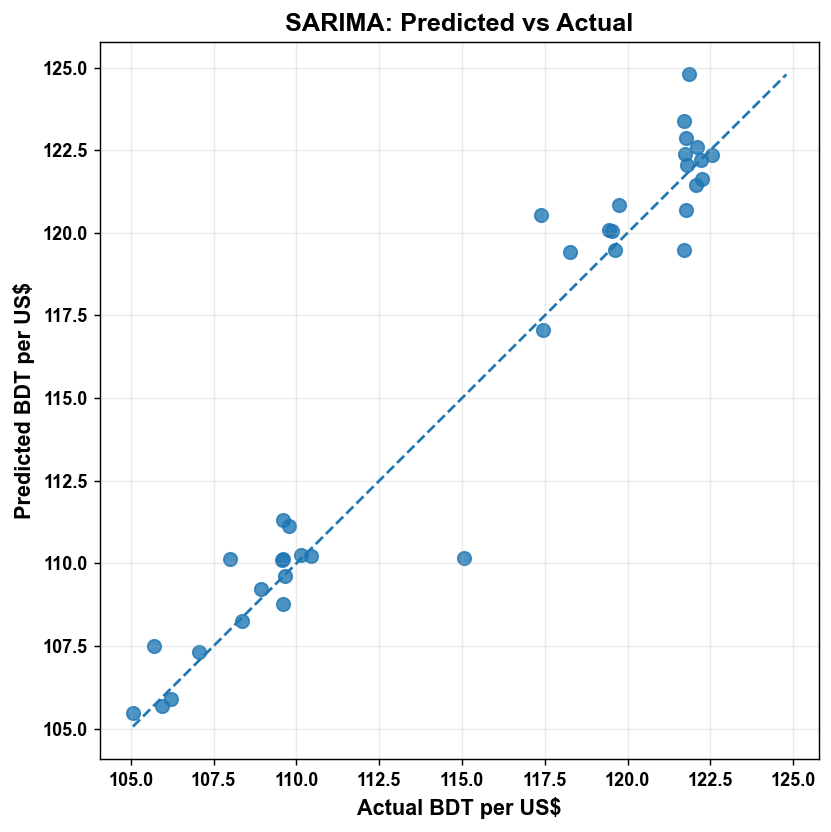

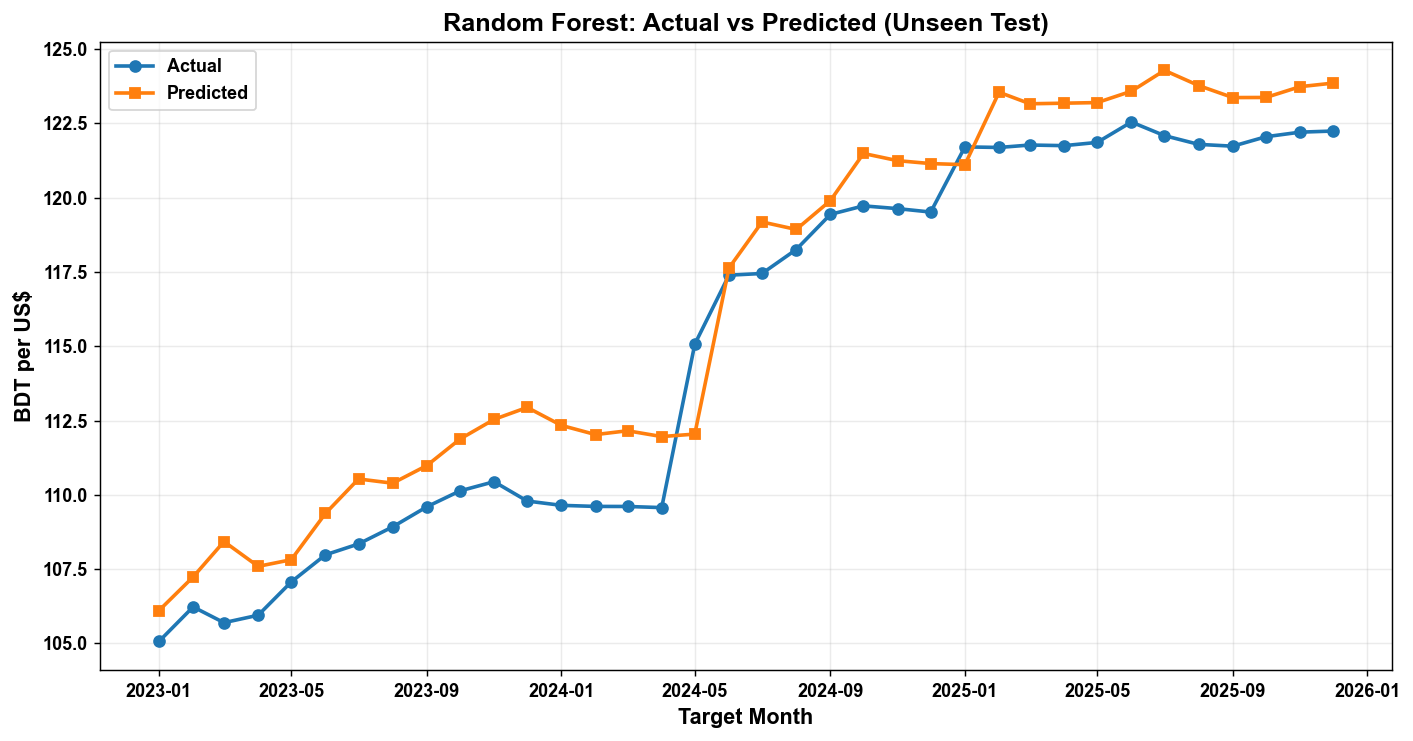

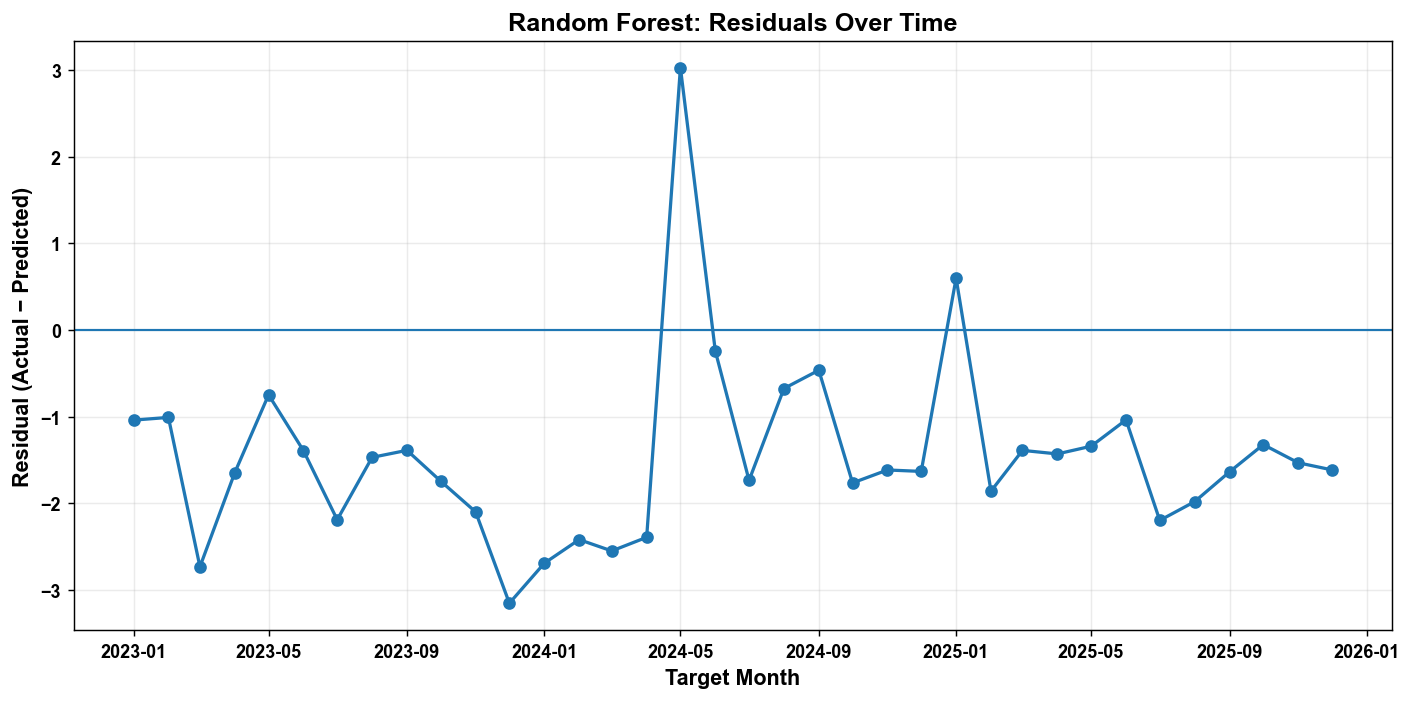

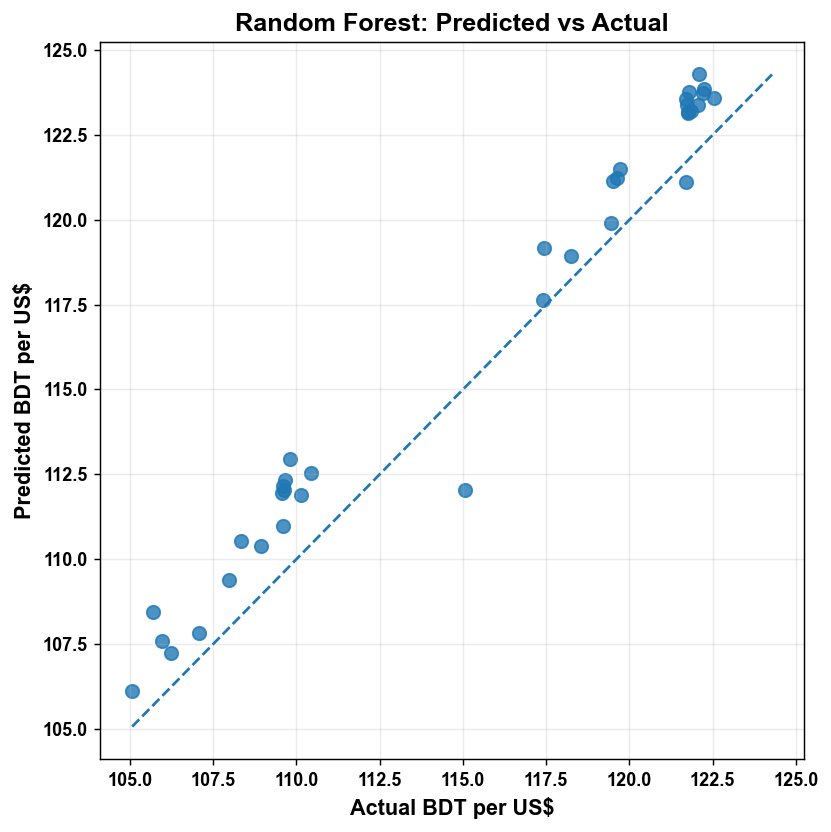

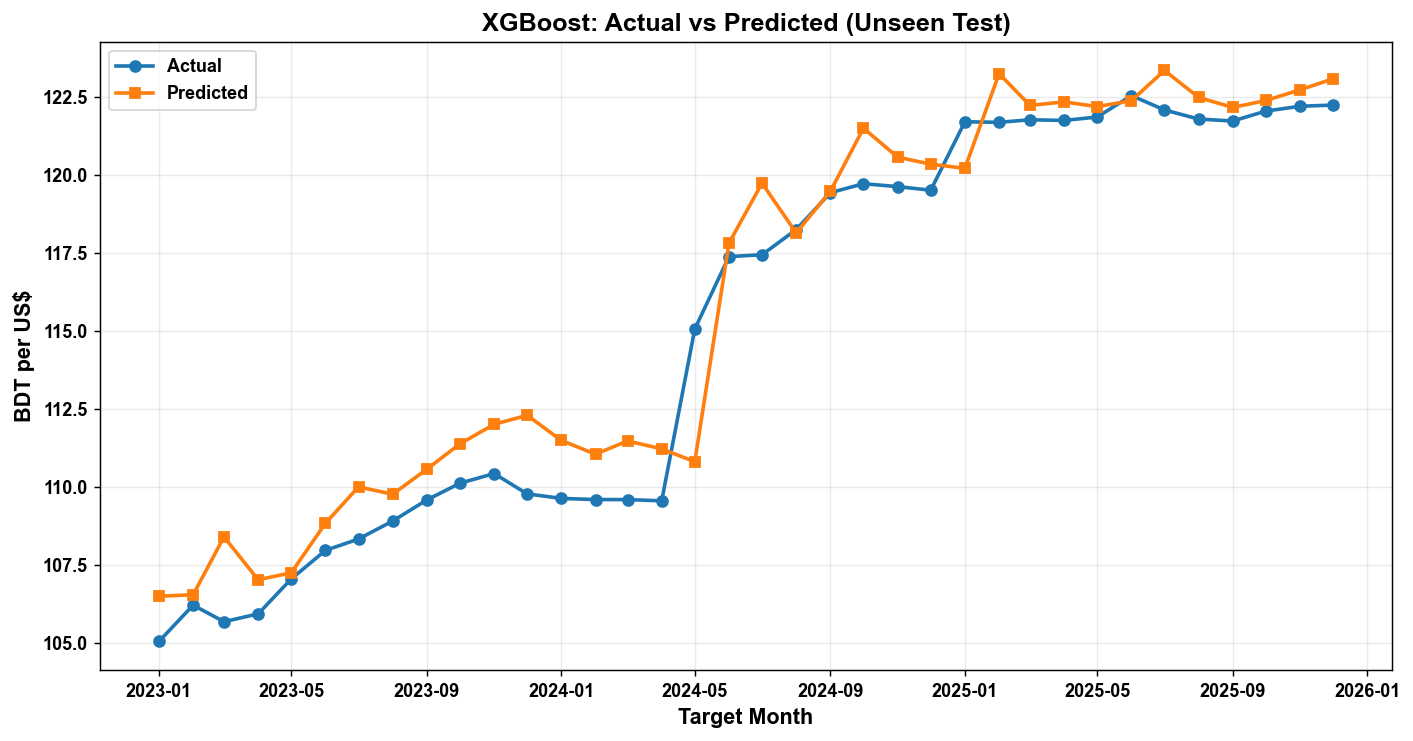

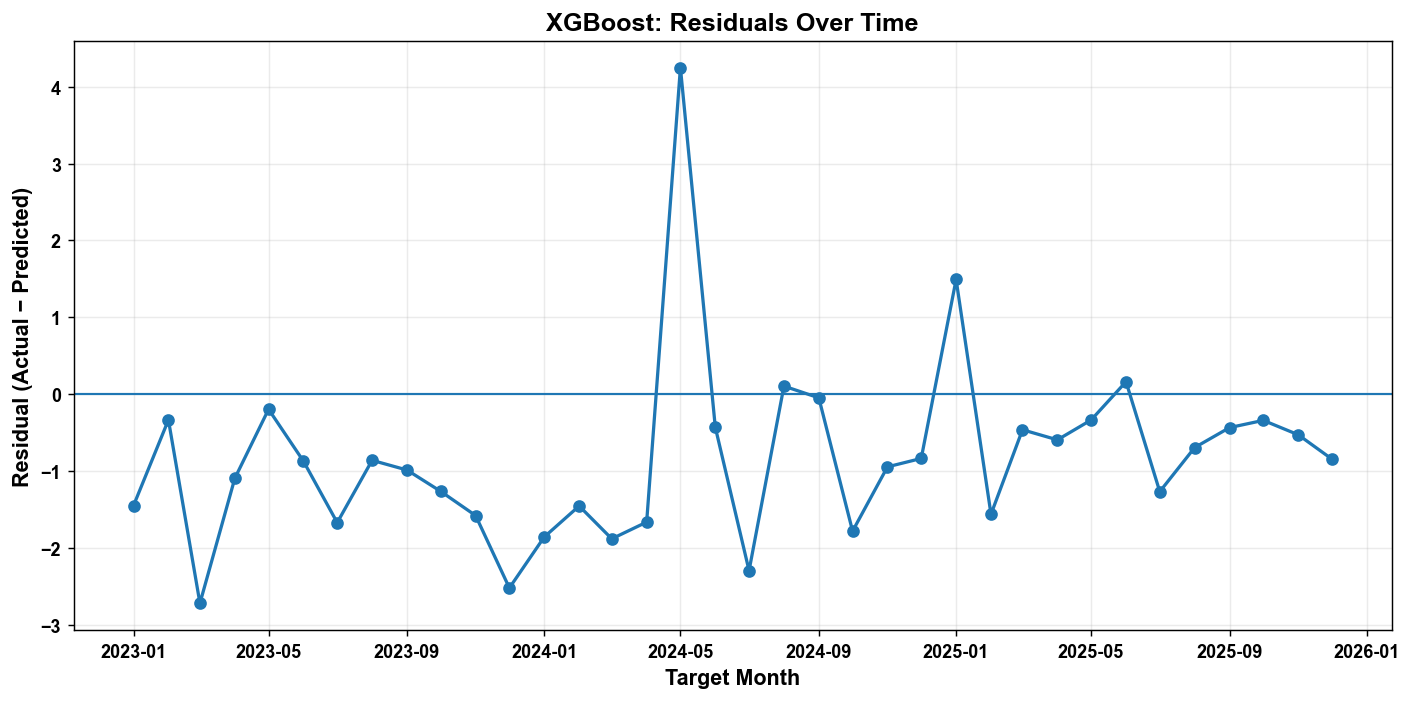

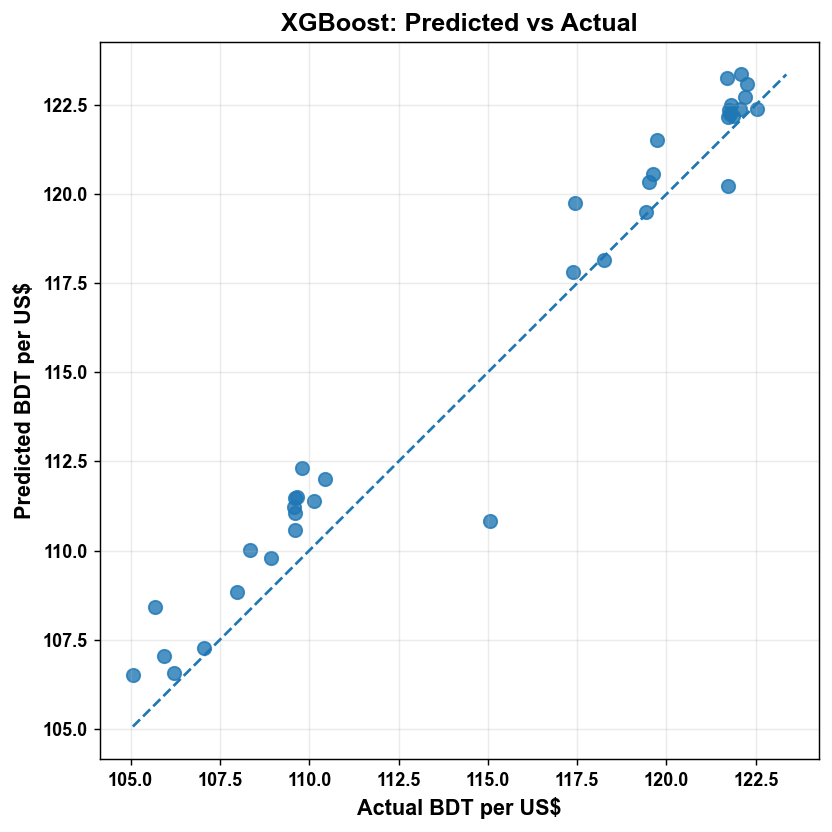

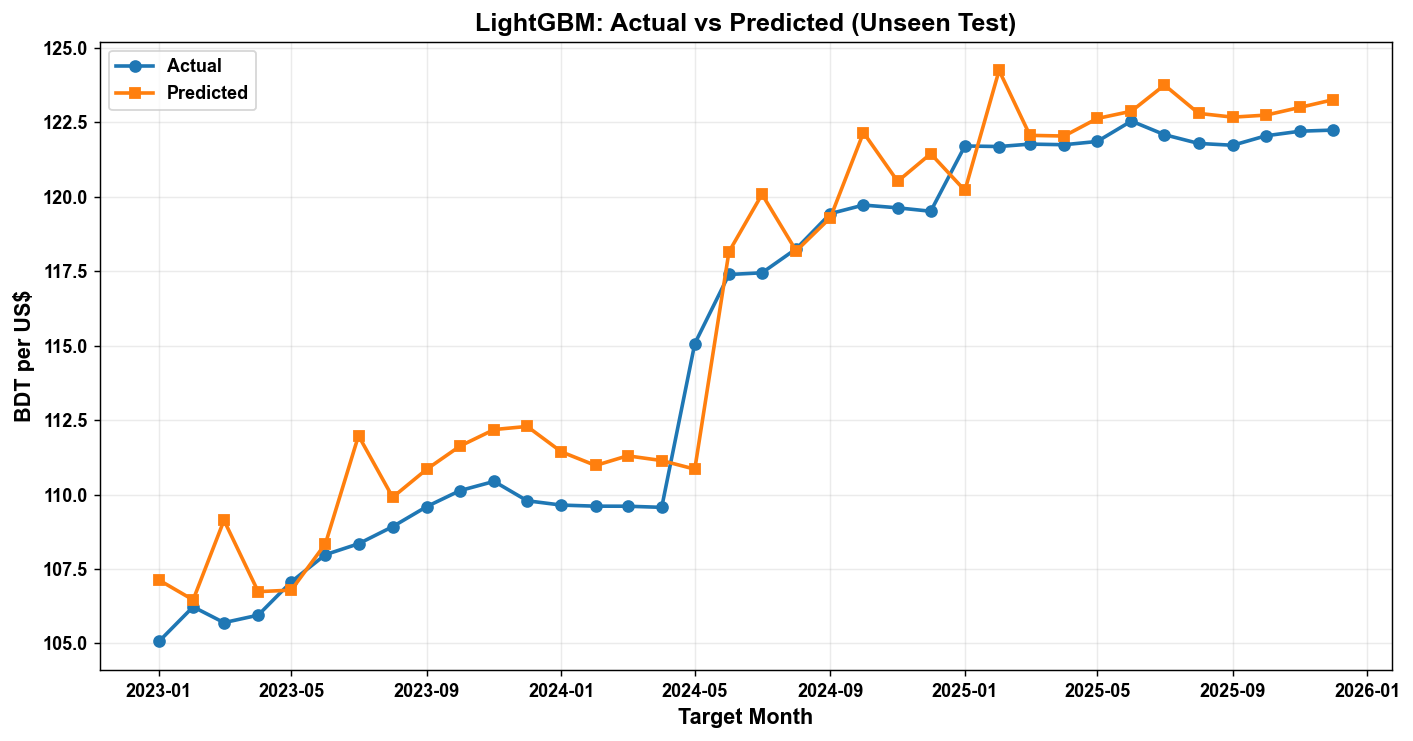

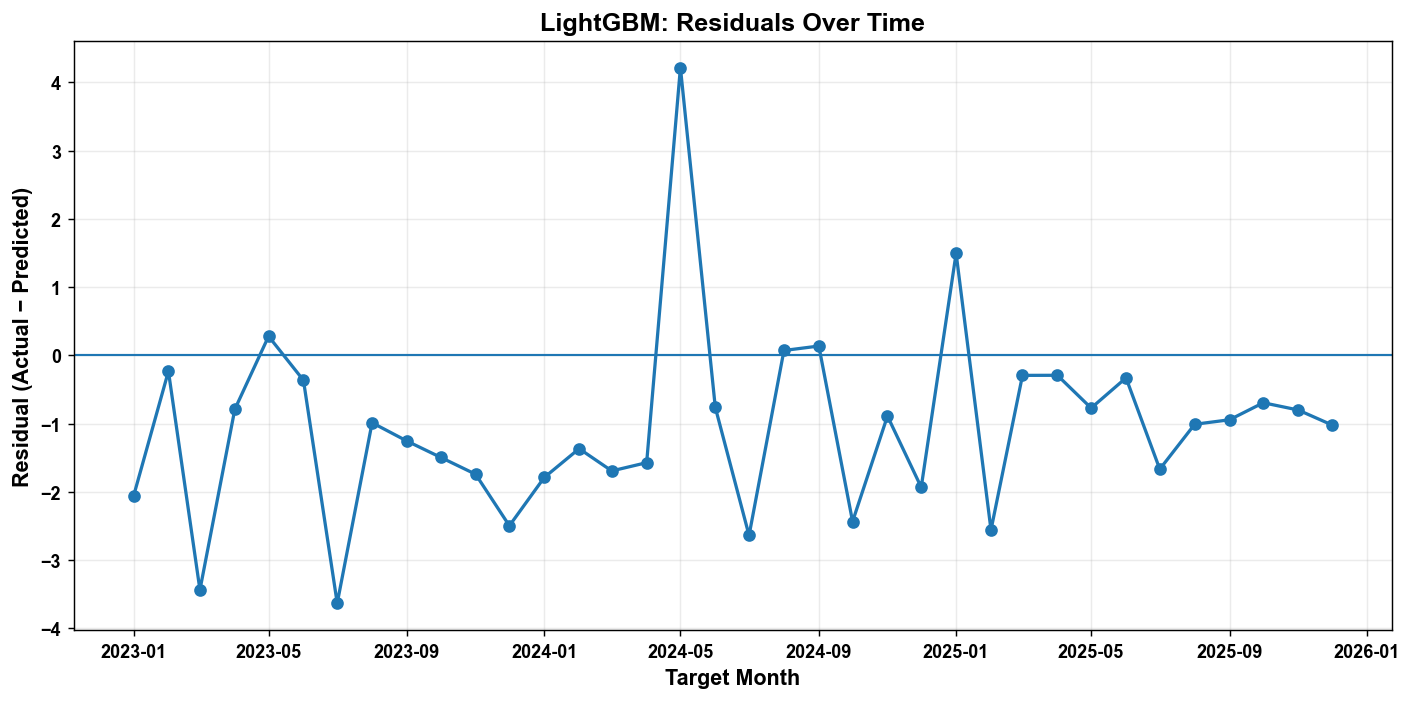

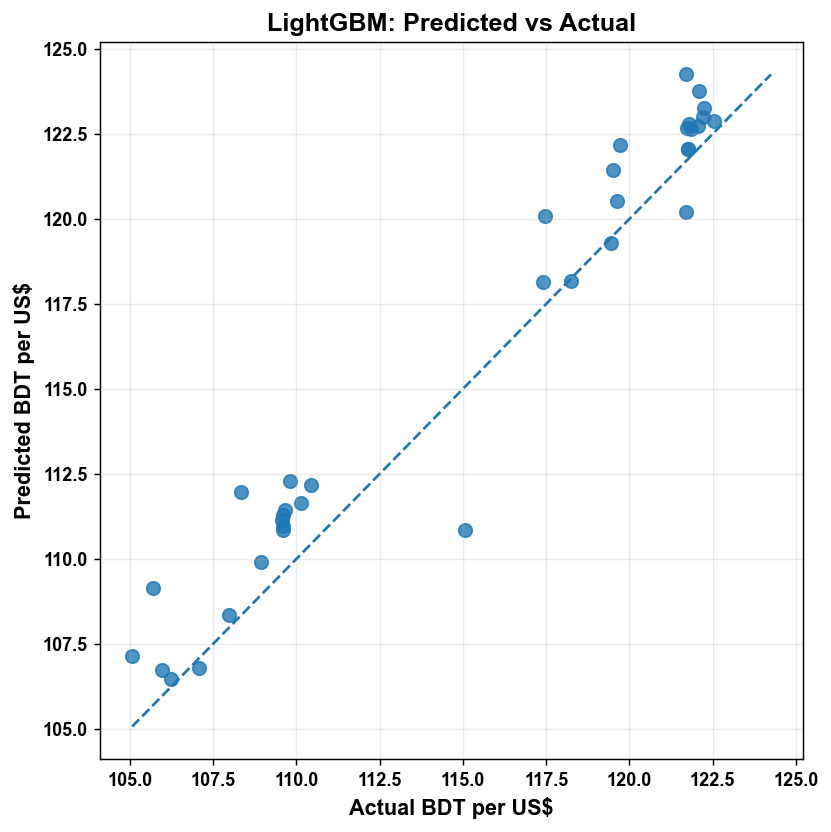

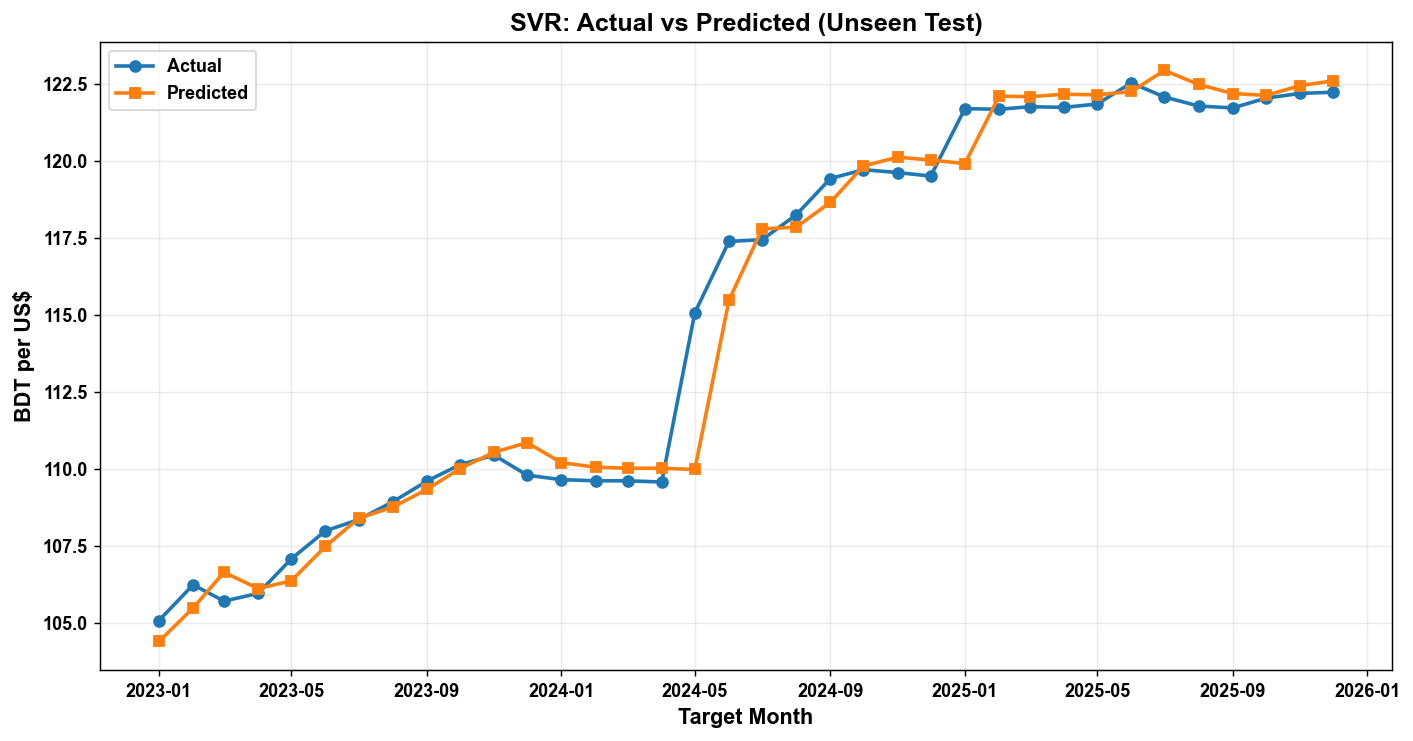

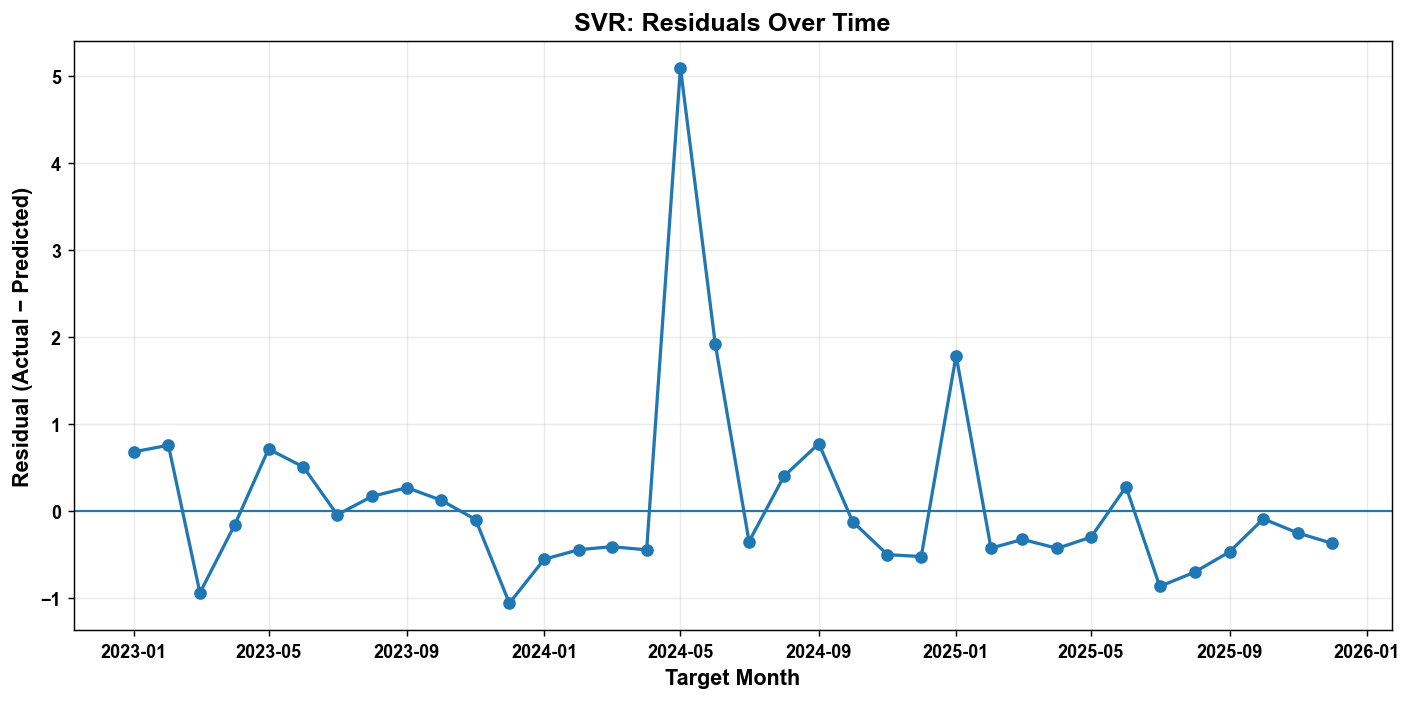

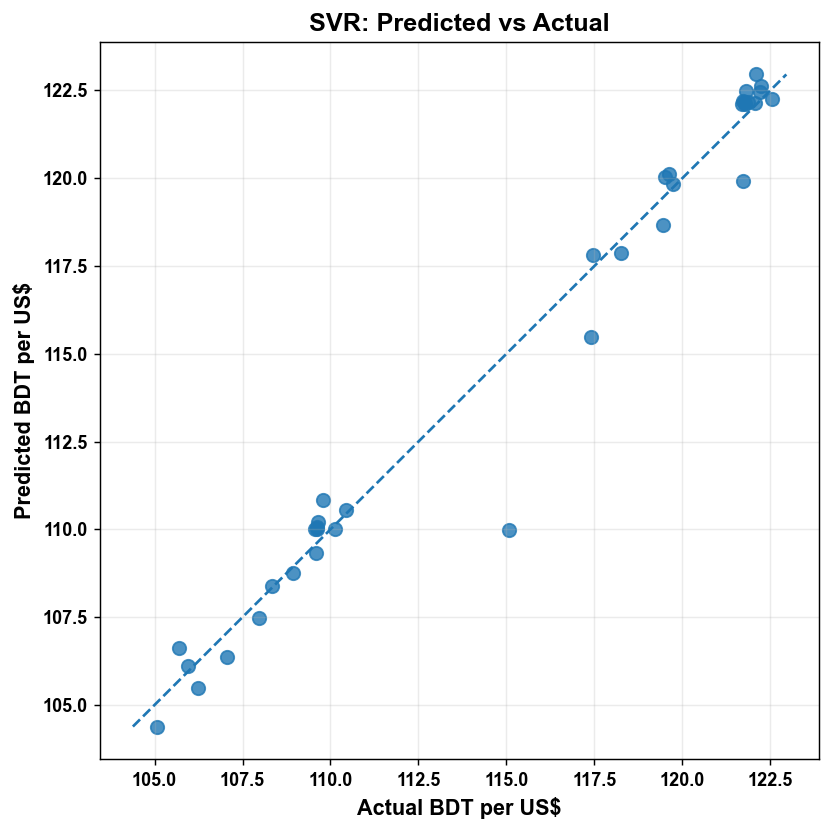

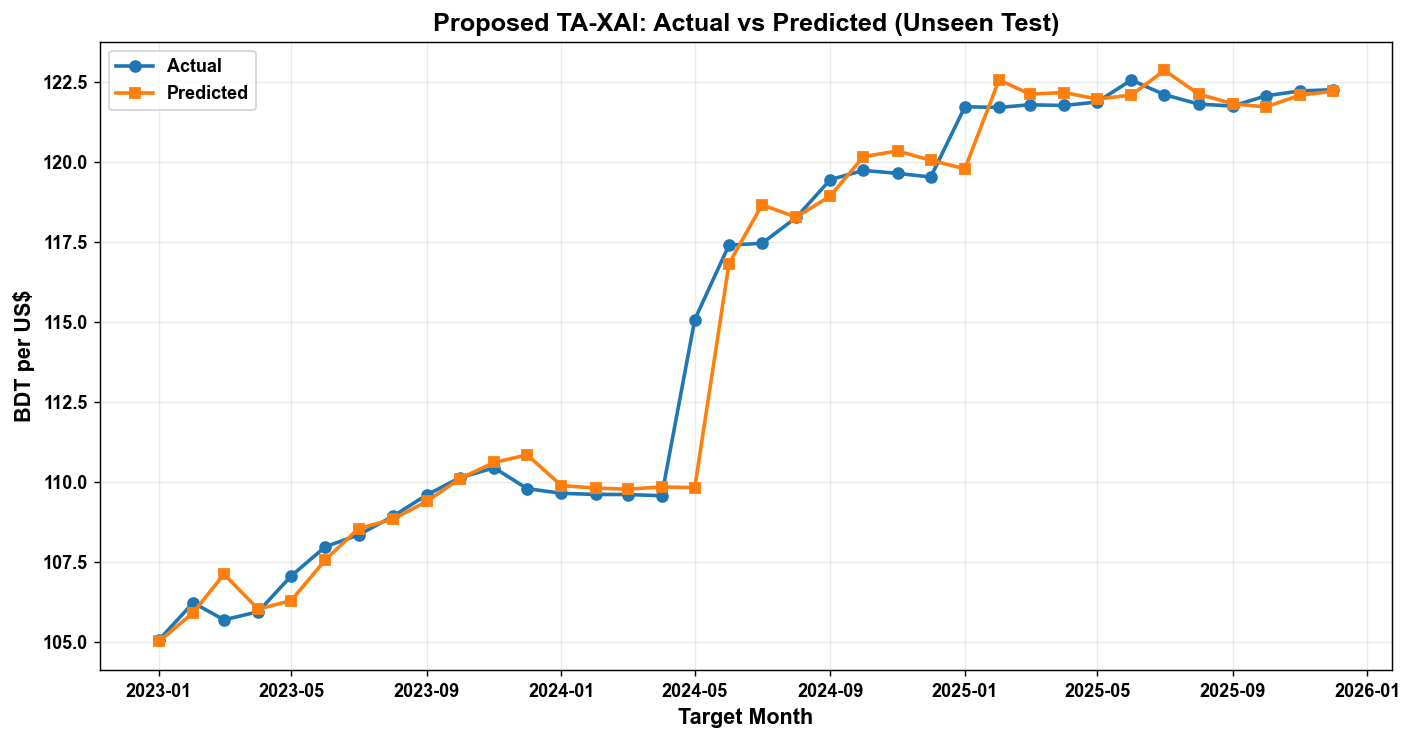

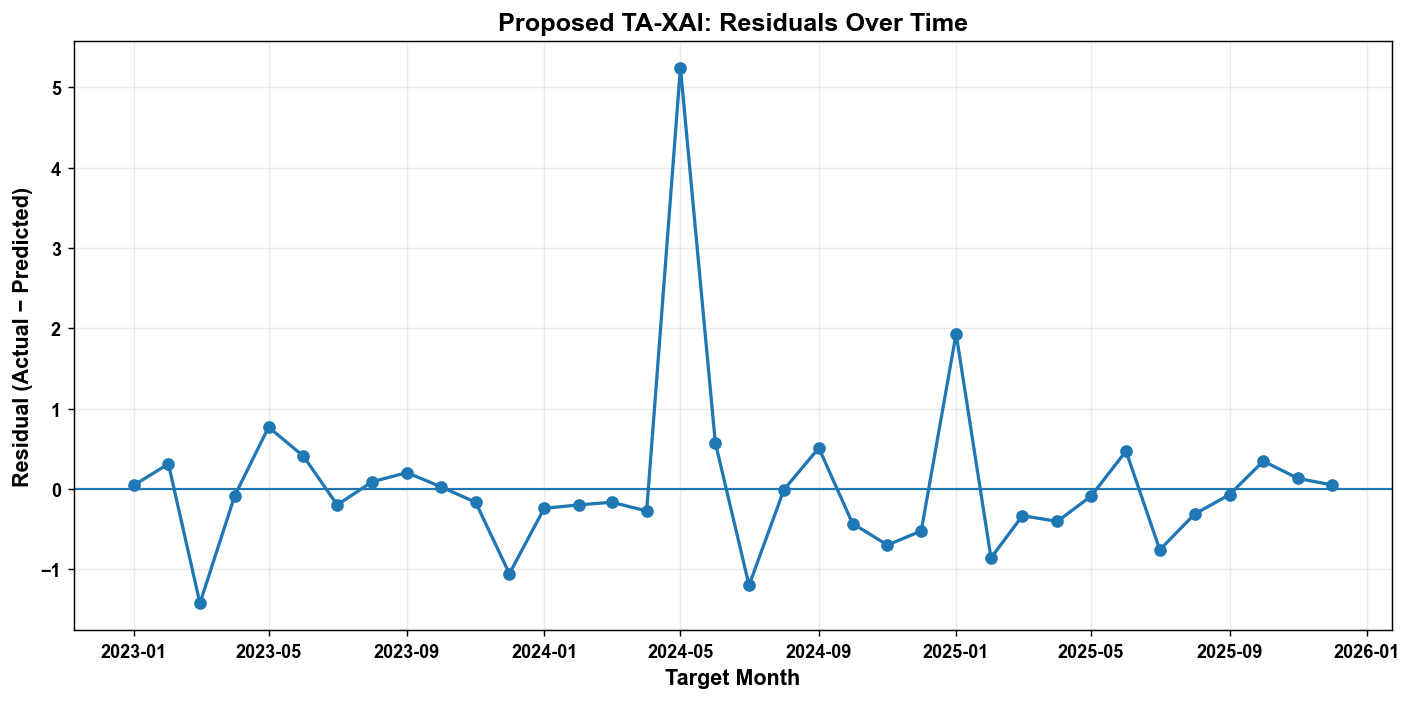

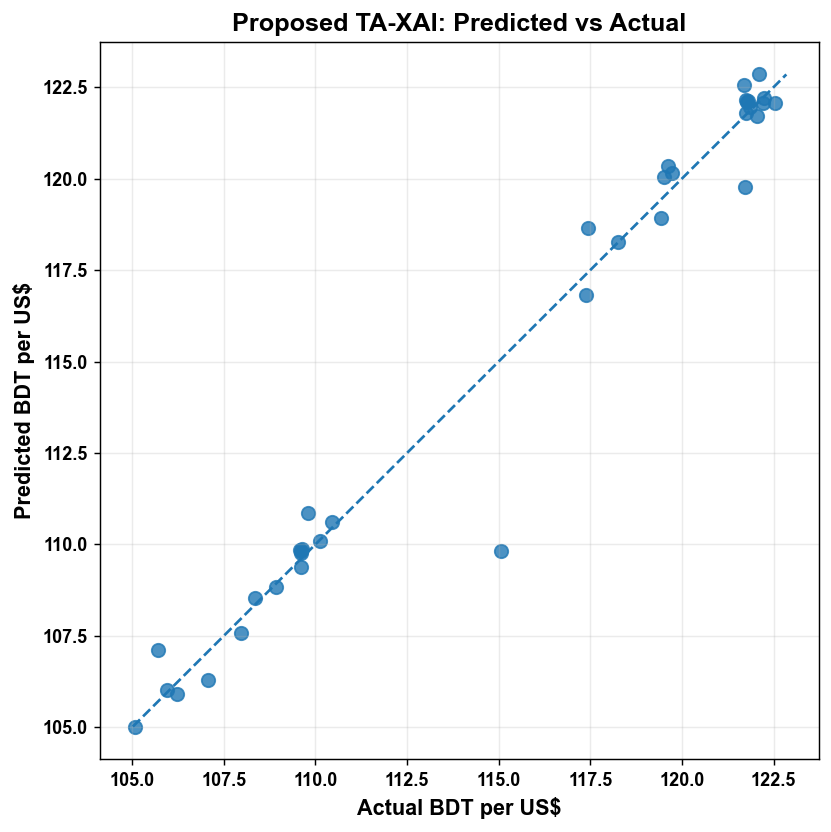

In [10]:
predictions = {
    'SARIMA': sarima_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred,
    'LightGBM': lgb_pred,
    'SVR': svr_pred,
    'Proposed TA-XAI': proposed_pred
}

metrics = pd.DataFrame([
    metric_row(name, y_test_level, pred, current_test_level)
    for name,pred in predictions.items()
]).sort_values('RMSE').reset_index(drop=True)
metrics.to_csv(TABLE_DIR/'07_final_test_metrics.csv',index=False)

display(metrics.style.format({
    'R2':'{:.4f}', 'Explained_Variance_pct':'{:.2f}', 'RMSE':'{:.4f}', 'MAE':'{:.4f}',
    'sMAPE_pct':'{:.3f}', 'MASE':'{:.3f}', 'Directional_Accuracy_pct':'{:.2f}', 'Theil_U_vs_Naive':'{:.3f}'
}))

best_name = metrics.iloc[0]['Model']
print('Best model by unseen-test RMSE:', best_name)
prop_row = metrics[metrics.Model=='Proposed TA-XAI'].iloc[0]
print(f"Proposed TA-XAI R² = {prop_row.R2:.4f} ({prop_row.Explained_Variance_pct:.2f}% explained variance)")
print(f"Proposed RMSE = {prop_row.RMSE:.4f} | MAE = {prop_row.MAE:.4f} | sMAPE = {prop_row.sMAPE_pct:.3f}%")

# Per-model paper figures.
for name,pred in predictions.items():
    common_model_figures(name, test_dates, current_test_level, y_test_level, pred)

## 10. Final six-model comparison figure

This figure reports the actual unseen-test results. It does not rescale or manipulate scores to force a winner.

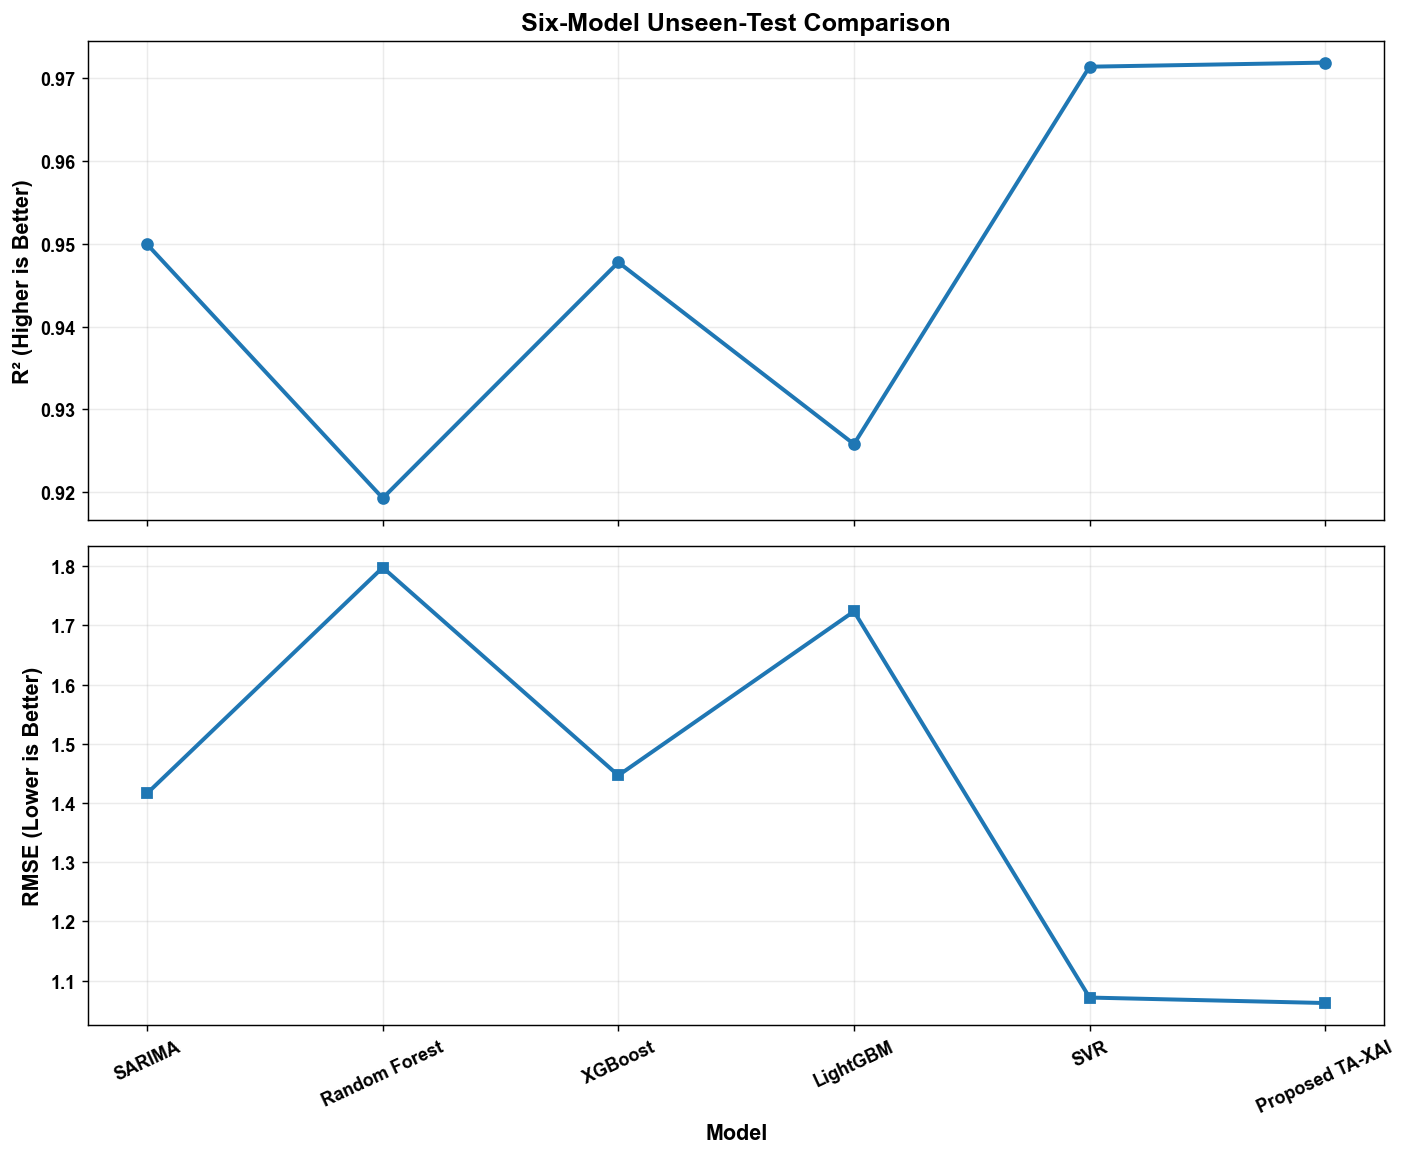

In [11]:
order=['SARIMA','Random Forest','XGBoost','LightGBM','SVR','Proposed TA-XAI']
cmp=metrics.set_index('Model').loc[order].reset_index()
fig, axes = plt.subplots(2,1,figsize=(11,9),sharex=True)
axes[0].plot(cmp['Model'], cmp['R2'], marker='o', linewidth=2.2)
axes[0].set_ylabel('R² (Higher is Better)', fontweight='bold')
axes[0].set_title('Six-Model Unseen-Test Comparison', fontweight='bold')
axes[0].grid(alpha=.25)
axes[1].plot(cmp['Model'], cmp['RMSE'], marker='s', linewidth=2.2)
axes[1].set_ylabel('RMSE (Lower is Better)', fontweight='bold')
axes[1].set_xlabel('Model', fontweight='bold')
axes[1].grid(alpha=.25)
for ax in axes:
    ax.tick_params(axis='x', rotation=25)
    for tick in ax.get_xticklabels(): tick.set_fontweight('bold')
plt.tight_layout(); plt.savefig(FIG_DIR/'Fig_Final_6_Model_Comparison.png'); plt.show()

## 11. Explainable AI for all six models

- SARIMA: parameter influence
- Random Forest / XGBoost / LightGBM: mean absolute SHAP contribution
- SVR: permutation importance
- Proposed TA-XAI: standardized coefficient importance + linear SHAP beeswarm

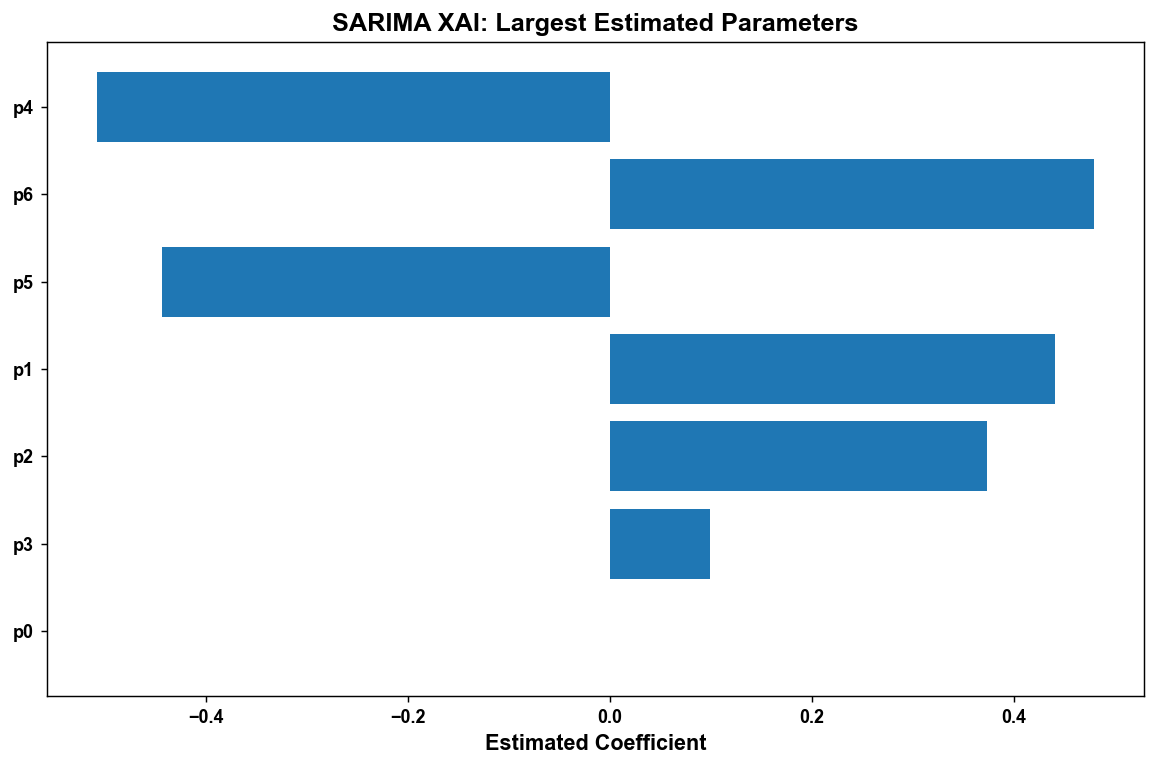

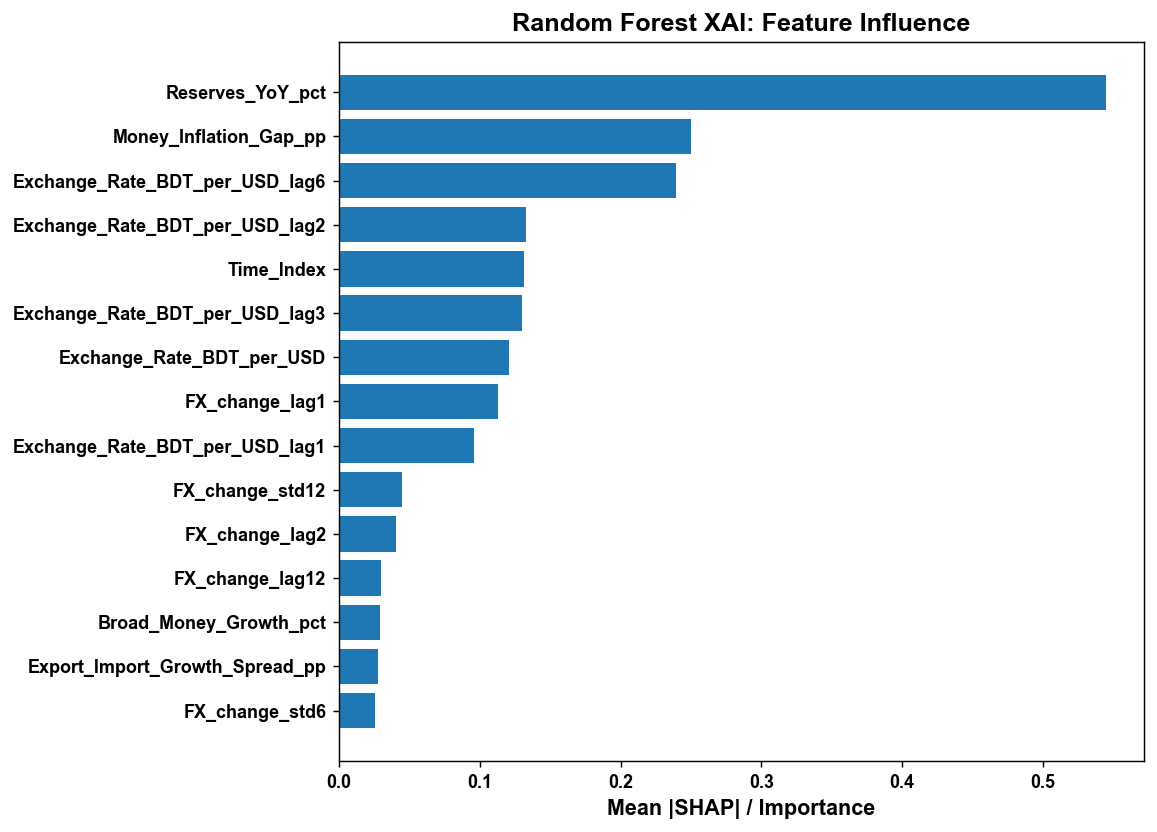

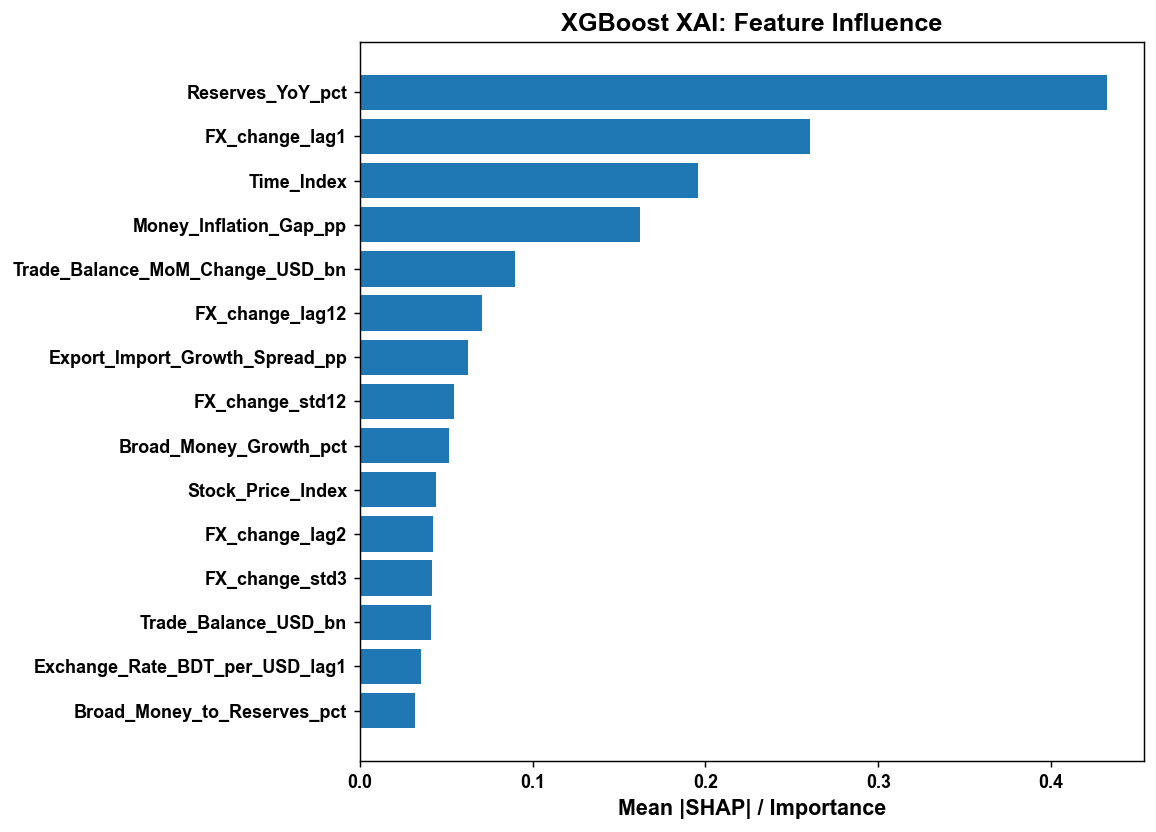

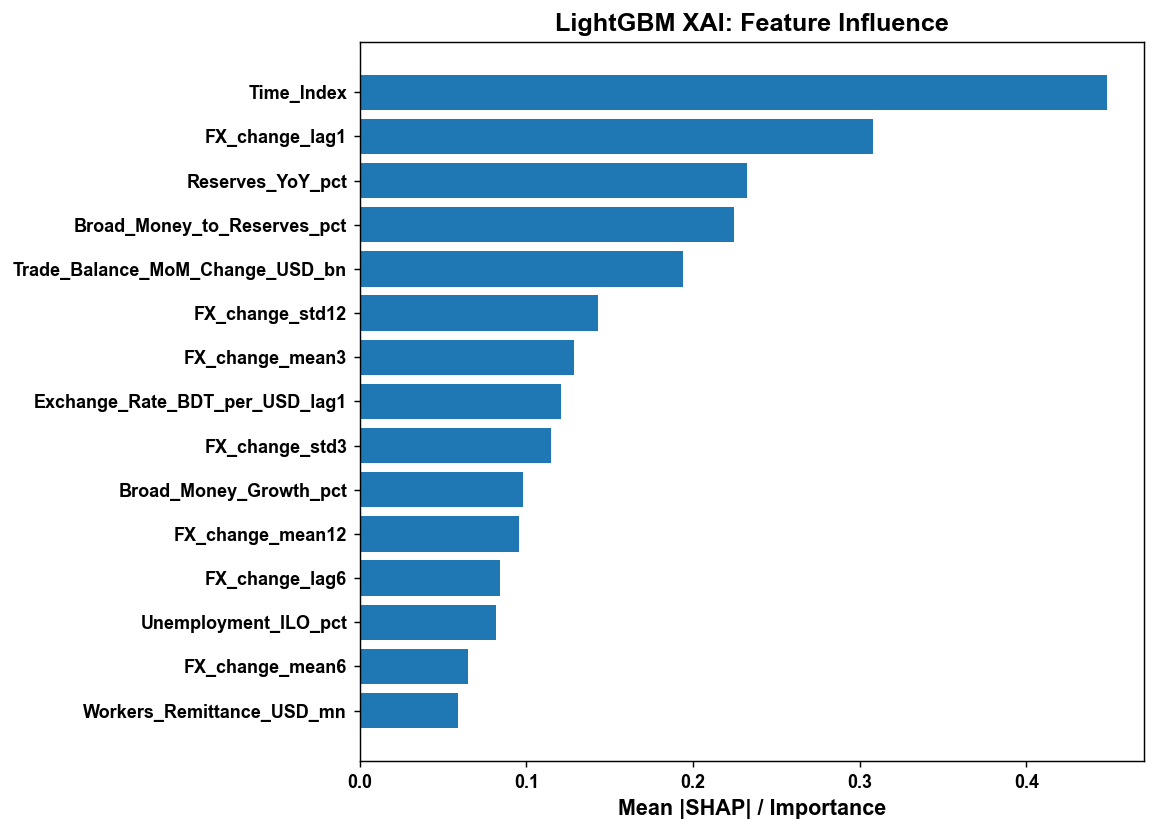

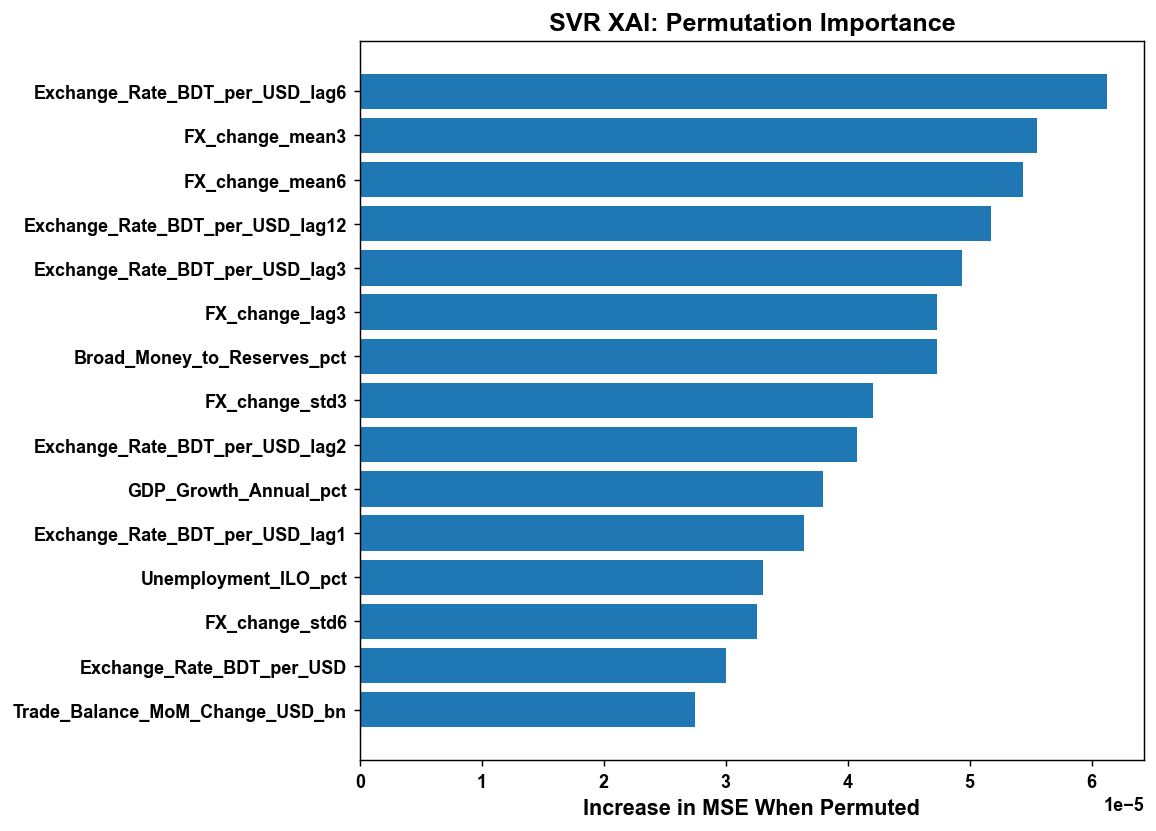

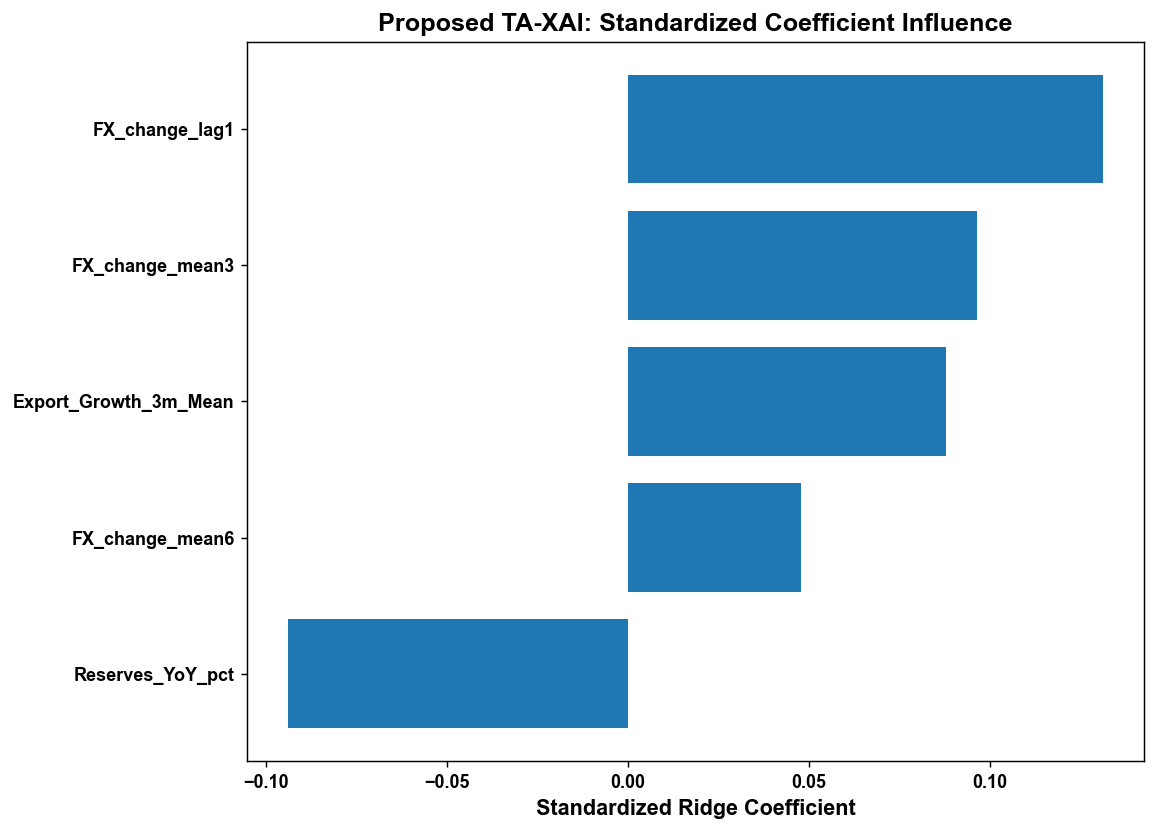

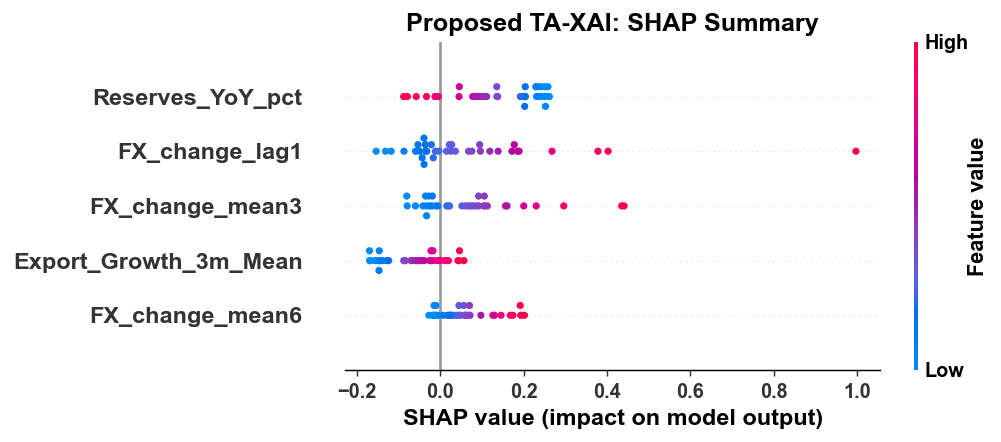

In [12]:
# --- SARIMA parameter influence ---
params = sarima_fit_end.params
if hasattr(params,'dropna'): params=params.dropna()
params = pd.Series(np.asarray(params).reshape(-1), index=getattr(sarima_fit_end.params,'index', [f'p{i}' for i in range(len(np.asarray(params).reshape(-1))) ]))
top = params.reindex(params.abs().sort_values(ascending=False).head(15).index)
fig,ax=plt.subplots(figsize=(9,6)); ax.barh(top.index.astype(str), top.values); ax.invert_yaxis()
ax.set_title('SARIMA XAI: Largest Estimated Parameters',fontweight='bold'); ax.set_xlabel('Estimated Coefficient',fontweight='bold')
plt.tight_layout(); plt.savefig(FIG_DIR/'XAI_SARIMA_Parameters.png'); plt.show()

# Helper for tree SHAP bar charts on delta forecasts.
def tree_shap_bar(model, X, name, max_display=15):
    Xs=X.copy()
    try:
        explainer=shap.TreeExplainer(model)
        sv=explainer.shap_values(Xs)
        if isinstance(sv,list): sv=sv[0]
        imp=np.abs(np.asarray(sv)).mean(axis=0)
        s=pd.Series(imp,index=Xs.columns).sort_values(ascending=False).head(max_display).sort_values()
    except Exception:
        pi=permutation_importance(model,Xs,y_test_delta,n_repeats=20,random_state=SEED,scoring='neg_mean_squared_error')
        s=pd.Series(pi.importances_mean,index=Xs.columns).sort_values(ascending=False).head(max_display).sort_values()
    fig,ax=plt.subplots(figsize=(9,6.5)); ax.barh(s.index,s.values)
    ax.set_title(f'{name} XAI: Feature Influence',fontweight='bold'); ax.set_xlabel('Mean |SHAP| / Importance',fontweight='bold')
    plt.tight_layout(); plt.savefig(FIG_DIR/f'XAI_{name.replace(" ","_")}.png'); plt.show()

tree_shap_bar(rf_model, X_test, 'Random Forest')
tree_shap_bar(xgb_model, X_test, 'XGBoost')
tree_shap_bar(lgb_model, X_test, 'LightGBM')

# SVR permutation importance on next-month change.
pi=permutation_importance(svr_model,X_test,y_test_delta,n_repeats=30,random_state=SEED,scoring='neg_mean_squared_error')
s=pd.Series(pi.importances_mean,index=X_test.columns).sort_values(ascending=False).head(15).sort_values()
fig,ax=plt.subplots(figsize=(9,6.5)); ax.barh(s.index,s.values)
ax.set_title('SVR XAI: Permutation Importance',fontweight='bold'); ax.set_xlabel('Increase in MSE When Permuted',fontweight='bold')
plt.tight_layout(); plt.savefig(FIG_DIR/'XAI_SVR_Permutation_Importance.png'); plt.show()

# Proposed TA-XAI standardized coefficients.
scaler=proposed_model.named_steps['scale']; ridge=proposed_model.named_steps['ridge']
coef=pd.Series(ridge.coef_,index=prop_features).sort_values(key=np.abs,ascending=False)
fig,ax=plt.subplots(figsize=(9,6.5)); topc=coef.head(15).sort_values()
ax.barh(topc.index,topc.values)
ax.set_title('Proposed TA-XAI: Standardized Coefficient Influence',fontweight='bold'); ax.set_xlabel('Standardized Ridge Coefficient',fontweight='bold')
plt.tight_layout(); plt.savefig(FIG_DIR/'XAI_Proposed_Coefficients.png'); plt.show()

# Linear SHAP values relative to the Train+Validation mean after scaling (approximately zero).
Xte_scaled=scaler.transform(X_test[prop_features])
shap_vals=Xte_scaled * ridge.coef_.reshape(1,-1)
try:
    shap.summary_plot(shap_vals, X_test[prop_features], feature_names=prop_features, max_display=min(15,len(prop_features)), show=False)
    plt.title('Proposed TA-XAI: SHAP Summary',fontweight='bold')
    plt.tight_layout(); plt.savefig(FIG_DIR/'XAI_Proposed_SHAP_Summary.png'); plt.show()
except Exception:
    mean_abs=pd.Series(np.abs(shap_vals).mean(axis=0),index=prop_features).sort_values(ascending=False).head(15).sort_values()
    fig,ax=plt.subplots(figsize=(9,6.5)); ax.barh(mean_abs.index,mean_abs.values)
    ax.set_title('Proposed TA-XAI: Mean Absolute SHAP Contribution',fontweight='bold')
    plt.tight_layout(); plt.savefig(FIG_DIR/'XAI_Proposed_SHAP_Summary.png'); plt.show()

## 12. Residual diagnostics and Diebold–Mariano significance tests

In [13]:
resid_rows=[]
for name,pred in predictions.items():
    resid=np.asarray(y_test_level)-np.asarray(pred)
    lb=acorr_ljungbox(resid,lags=[min(6,len(resid)//4)],return_df=True)
    resid_rows.append({'Model':name,'Residual_Mean':resid.mean(),'Residual_SD':resid.std(ddof=1),
                       'LjungBox_p':float(lb['lb_pvalue'].iloc[0])})
resid_table=pd.DataFrame(resid_rows)
resid_table.to_csv(TABLE_DIR/'08_residual_diagnostics.csv',index=False)
display(resid_table.round(4))

dm_rows=[]
for name,pred in predictions.items():
    if name=='Proposed TA-XAI': continue
    stat,p=dm_test(y_test_level,pred,proposed_pred,h=1)
    dm_rows.append({'Compared_Model':name,'DM_Statistic':stat,'p_value':p,
                    'Lower_MSE_Model':'Proposed TA-XAI' if rmse(y_test_level,proposed_pred)<rmse(y_test_level,pred) else name})
dm_table=pd.DataFrame(dm_rows)
dm_table.to_csv(TABLE_DIR/'09_Diebold_Mariano_vs_Proposed.csv',index=False)
display(dm_table.round(4))

,Model,Residual_Mean,Residual_SD,LjungBox_p
0,SARIMA,-0.3040,1.4031,0.0388
1,Random Forest,-1.4578,1.0668,0.3875
2,XGBoost,-0.8263,1.2043,0.5035
3,LightGBM,-1.0490,1.3870,0.4422
4,SVR,0.1000,1.0820,0.3915
5,Proposed TA-XAI,0.0450,1.0764,0.3153


,Compared_Model,DM_Statistic,p_value,Lower_MSE_Model
0,SARIMA,2.2738,0.0230,Proposed TA-XAI
1,Random Forest,3.0373,0.0024,Proposed TA-XAI
2,XGBoost,2.4380,0.0148,Proposed TA-XAI
3,LightGBM,3.1226,0.0018,Proposed TA-XAI
4,SVR,0.1656,0.8684,Proposed TA-XAI


## 13. 100-round moving-block bootstrap confidence intervals

A moving-block bootstrap preserves short-range temporal dependence better than ordinary row resampling.

In [14]:
ci_rows=[]
for name,pred in predictions.items():
    row={'Model':name}
    row.update(moving_block_bootstrap_metrics(y_test_level,pred,current_test_level,B=N_BOOTSTRAP,block=6,seed=SEED))
    ci_rows.append(row)
ci_table=pd.DataFrame(ci_rows)
ci_table.to_csv(TABLE_DIR/'10_bootstrap_95CI_100_rounds.csv',index=False)
display(ci_table.round(4))

,Model,R2_CI_low,R2_CI_high,RMSE_CI_low,RMSE_CI_high,MAE_CI_low,MAE_CI_high,sMAPE_pct_CI_low,sMAPE_pct_CI_high,MASE_CI_low,MASE_CI_high,Directional_Accuracy_pct_CI_low,Directional_Accuracy_pct_CI_high
0,SARIMA,0.8004,0.9697,1.0822,1.9252,0.7399,1.3593,0.6505,1.1713,2.7509,5.0537,41.6667,77.7778
1,Random Forest,0.7868,0.9444,1.4795,2.1294,1.3719,1.9912,1.1710,1.7582,5.1004,7.4029,45.7639,79.2361
2,XGBoost,0.8363,0.9735,1.0006,1.8241,0.8592,1.5418,0.7347,1.3713,3.1945,5.7320,45.7639,79.2361
3,LightGBM,0.7950,0.9500,1.4368,1.9624,1.1182,1.6806,0.9500,1.4996,4.1571,6.2482,45.7639,79.2361
4,SVR,0.8619,0.9940,0.5030,1.6483,0.3932,0.9715,0.3462,0.8515,1.4617,3.6120,45.7639,79.2361
5,Proposed TA-XAI,0.8651,0.9940,0.4887,1.6266,0.3559,0.8756,0.3055,0.7632,1.3233,3.2554,41.6667,79.2361


## 14. Expanding-window yearly robustness backtest

The final tuned configurations are re-estimated repeatedly using only data available before each evaluation year. This checks whether a strong result depends on one lucky split.

Model,LightGBM,Proposed TA-XAI,Random Forest,SARIMA,SVR,XGBoost
Year,,,,,,
2020,0.128,0.114,0.102,0.207,0.227,0.065
2021,0.240,0.250,0.221,0.131,0.189,0.196
2022,2.128,1.832,1.774,1.752,2.090,1.771
2023,1.920,0.586,1.849,1.044,0.574,1.486
2024,1.593,1.600,1.631,1.850,1.630,1.709
2025,0.750,0.684,1.350,1.195,0.698,0.929


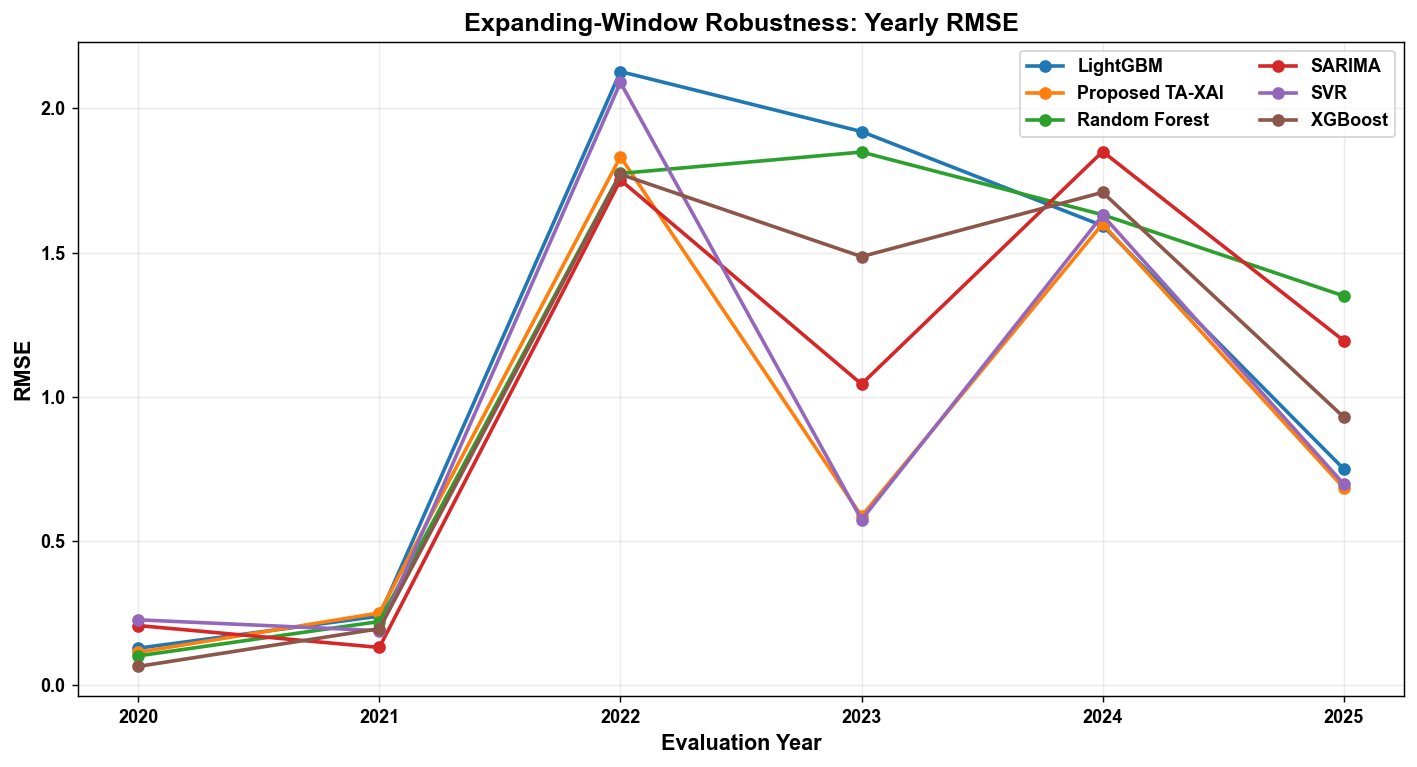

In [15]:
def fitted_ml_from_best(name, Xtr, ytr):
    if name=='Random Forest': est=clone(rf_best[2])
    elif name=='XGBoost': est=clone(xgb_best[2])
    elif name=='LightGBM': est=clone(lgb_best[2])
    elif name=='SVR': est=clone(svr_best[2])
    else: raise ValueError(name)
    est.fit(Xtr,ytr); return est

backtest_rows=[]
for yr in range(2020,2026):
    fold_train=model_df[model_df.Target_Month < pd.Timestamp(f'{yr}-01-01')]
    fold_test=model_df[(model_df.Target_Month >= pd.Timestamp(f'{yr}-01-01')) & (model_df.Target_Month <= pd.Timestamp(f'{yr}-12-01'))]
    if len(fold_test)==0 or len(fold_train)<60: continue
    Xf=fold_train[feature_pool]; yf=fold_train.Target_Change
    Xo=fold_test[feature_pool]; truef=fold_test.Target_Level.to_numpy(float); curf=fold_test[TARGET_COL].to_numpy(float)

    for name in ['Random Forest','XGBoost','LightGBM','SVR']:
        est=fitted_ml_from_best(name,Xf,yf)
        pred=curf+est.predict(Xo)
        backtest_rows.append({'Year':yr,'Model':name,'RMSE':rmse(truef,pred),'R2':r2_score(truef,pred)})

    # Proposed with the same preselected structure; only coefficients are re-estimated.
    prop=Pipeline([('scale',StandardScaler()),('ridge',Ridge(alpha=prop_alpha))])
    prop.fit(fold_train[prop_features],yf)
    pred=curf+prop.predict(fold_test[prop_features])
    backtest_rows.append({'Year':yr,'Model':'Proposed TA-XAI','RMSE':rmse(truef,pred),'R2':r2_score(truef,pred)})

    # SARIMA one-step walk-forward for the year.
    hist=level_series.loc[:pd.Timestamp(f'{yr-1}-12-01')].to_numpy(float)
    act=level_series.loc[pd.Timestamp(f'{yr}-01-01'):pd.Timestamp(f'{yr}-12-01')].to_numpy(float)
    try:
        sp,_=sarima_walk_forward(hist,act,best_sar[1],best_sar[2],trend='t')
        backtest_rows.append({'Year':yr,'Model':'SARIMA','RMSE':rmse(act,sp),'R2':r2_score(act,sp)})
    except Exception:
        pass

backtest=pd.DataFrame(backtest_rows)
backtest.to_csv(TABLE_DIR/'11_expanding_yearly_backtest.csv',index=False)
display(backtest.pivot(index='Year',columns='Model',values='RMSE').round(3))

fig,ax=plt.subplots(figsize=(11,6))
for name,g in backtest.groupby('Model'):
    ax.plot(g.Year,g.RMSE,marker='o',linewidth=2,label=name)
ax.set_title('Expanding-Window Robustness: Yearly RMSE',fontweight='bold')
ax.set_xlabel('Evaluation Year',fontweight='bold'); ax.set_ylabel('RMSE',fontweight='bold')
ax.legend(ncol=2); ax.grid(alpha=.25)
plt.tight_layout(); plt.savefig(FIG_DIR/'Fig_Robustness_Yearly_RMSE.png'); plt.show()

## 15. True ex-ante 2026 forecast (no 2026 input rows used)

For deployment, TA-XAI is refit on all target observations available through Dec-2025. For Jan–Dec 2026, target-derived features are updated recursively from previous forecasts. Any selected exogenous macro-financial feature is projected using a **seasonal-naive path (same month of the previous year)**. This makes the 2026 output a genuine ex-ante forecast rather than a conditional forecast that secretly uses 2026 inputs.

,Target_Month,Forecast_BDT_per_USD,Forecast_Change
0,2026-01-01,122.5861,0.3411
1,2026-02-01,122.9775,0.3915
2,2026-03-01,123.3893,0.4118
3,2026-04-01,123.7765,0.3872
4,2026-05-01,124.1200,0.3434
5,2026-06-01,124.4334,0.3135
6,2026-07-01,124.6375,0.2041
7,2026-08-01,124.8253,0.1877
8,2026-09-01,124.9809,0.1557
9,2026-10-01,125.0777,0.0968


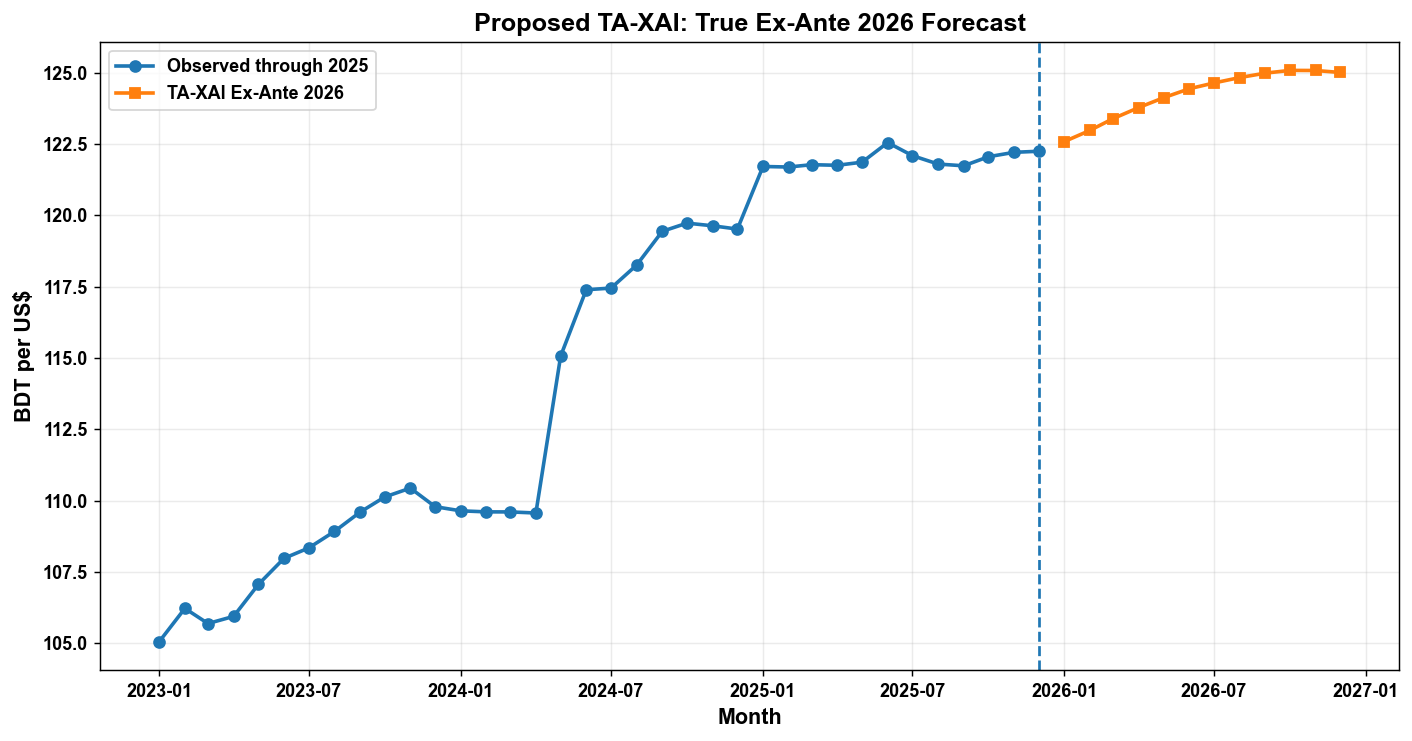

In [16]:
# Refit proposed model using all one-step targets ending by Dec-2025.
all_obs_model = model_df[model_df.Target_Month <= TEST_END].copy()
prop_deploy=Pipeline([('scale',StandardScaler()),('ridge',Ridge(alpha=prop_alpha))])
prop_deploy.fit(all_obs_model[prop_features],all_obs_model.Target_Change)

# Historical target levels through Dec-2025.
history = {pd.Timestamp(r.Month): float(r[TARGET_COL]) for _,r in obs_raw.iterrows()}
raw_by_month = obs_raw.set_index('Month')

# Helper: feature value at origin month using only pre-2026 history/seasonal-naive exogenous paths.
def recursive_feature(feature, origin, history_dict):
    origin=pd.Timestamp(origin)
    months=sorted(history_dict)
    def level_at(month): return history_dict[pd.Timestamp(month)]
    def chg_at(month):
        month=pd.Timestamp(month); prev=month-pd.offsets.MonthBegin(1)
        return level_at(month)-level_at(prev)

    if feature==TARGET_COL:
        return level_at(origin)
    if feature.startswith(f'{TARGET_COL}_lag'):
        lag=int(feature.split('lag')[-1]); return level_at(origin-pd.offsets.MonthBegin(lag))
    if feature.startswith('FX_change_lag'):
        lag=int(feature.split('lag')[-1]); m0=origin-pd.offsets.MonthBegin(lag-1); return chg_at(m0)
    if feature.startswith('FX_change_mean'):
        w=int(feature.replace('FX_change_mean','')); vals=[chg_at(origin-pd.offsets.MonthBegin(i)) for i in range(w)]; return float(np.mean(vals))
    if feature.startswith('FX_change_std'):
        w=int(feature.replace('FX_change_std','')); vals=[chg_at(origin-pd.offsets.MonthBegin(i)) for i in range(w)]; return float(np.std(vals,ddof=1))
    if feature=='FX_Depreciation_YoY_pct':
        return 100*(level_at(origin)/level_at(origin-pd.offsets.MonthBegin(12))-1)
    if feature=='Month_sin': return float(np.sin(2*np.pi*origin.month/12))
    if feature=='Month_cos': return float(np.cos(2*np.pi*origin.month/12))
    if feature=='Month_Number': return origin.month
    if feature=='Quarter': return (origin.month-1)//3+1
    if feature=='Year': return origin.year
    if feature=='Fiscal_Year_End': return origin.year if origin.month<=6 else origin.year+1
    if feature=='COVID_Shock_Flag': return 0
    if feature=='Time_Index':
        base_idx=float(obs_raw.loc[obs_raw.Month==OBSERVED_END,'Time_Index'].iloc[0]) if 'Time_Index' in obs_raw else len(obs_raw)
        return base_idx + ((origin.year-2025)*12 + origin.month-12)

    # Exogenous drivers: same month previous year, always from <=2025 for 2026 origins.
    ref=origin-pd.offsets.MonthBegin(12)
    if feature in raw_by_month.columns and ref in raw_by_month.index:
        return float(raw_by_month.loc[ref,feature])
    # Derived exogenous feature fallback: use the previous-year value from model_df if available.
    rows=model_df[model_df.Month==ref]
    if feature in model_df.columns and len(rows): return float(rows.iloc[0][feature])
    # Last-observed fallback, explicitly non-forward-looking.
    if feature in obs_raw.columns: return float(obs_raw[feature].iloc[-1])
    raise KeyError(feature)

forecast_rows=[]
origin=pd.Timestamp('2025-12-01')
for step in range(12):
    x={f:recursive_feature(f,origin,history) for f in prop_features}
    Xone=pd.DataFrame([x],columns=prop_features)
    delta=float(prop_deploy.predict(Xone)[0])
    next_month=origin+pd.offsets.MonthBegin(1)
    next_level=float(history[origin]+delta)
    forecast_rows.append({'Target_Month':next_month,'Forecast_BDT_per_USD':next_level,'Forecast_Change':delta})
    history[next_month]=next_level
    origin=next_month

forecast_2026=pd.DataFrame(forecast_rows)
forecast_2026.to_csv(TABLE_DIR/'12_TRUE_EX_ANTE_2026_TAXAI_FORECAST.csv',index=False)
display(forecast_2026.round(4))

fig,ax=plt.subplots(figsize=(11,5.8))
hist_plot=obs_raw[obs_raw.Month>=pd.Timestamp('2023-01-01')][['Month',TARGET_COL]]
ax.plot(hist_plot.Month,hist_plot[TARGET_COL],marker='o',linewidth=2,label='Observed through 2025')
ax.plot(forecast_2026.Target_Month,forecast_2026.Forecast_BDT_per_USD,marker='s',linewidth=2,label='TA-XAI Ex-Ante 2026')
ax.axvline(pd.Timestamp('2025-12-01'),linestyle='--',linewidth=1.5)
ax.set_title('Proposed TA-XAI: True Ex-Ante 2026 Forecast',fontweight='bold')
ax.set_xlabel('Month',fontweight='bold'); ax.set_ylabel('BDT per US$',fontweight='bold'); ax.legend(); ax.grid(alpha=.25)
plt.tight_layout(); plt.savefig(FIG_DIR/'Fig_2026_TRUE_ExAnte_TAXAI_Forecast.png'); plt.show()

## 16. Paper-ready final summary

In [17]:
print('='*100)
print('FINAL Q1-FOCUSED SUMMARY')
print('='*100)
print('Dataset rows / columns:', df.shape)
print('Observed modelling data used only through:', OBSERVED_END.date())
print('Test target period:', TEST_START.date(), 'to', TEST_END.date(), '| n =', len(test))
print('Main requested models: 6')
print('Best unseen-test model by RMSE:', metrics.iloc[0].Model)
print(f"Proposed TA-XAI R²: {prop_row.R2:.4f} ({prop_row.Explained_Variance_pct:.2f}% explained variance)")
print(f"Proposed RMSE: {prop_row.RMSE:.4f} | MAE: {prop_row.MAE:.4f} | sMAPE: {prop_row.sMAPE_pct:.3f}%")
print('Proposed selected features:', prop_features)
print('100-round moving-block bootstrap: completed')
print('2026 forecast uses no 2026 input rows: TRUE')
print('Unique dataset-analysis figure:', FIG_DIR/'Fig_01_Unique_MacroFinancial_Regime_Fingerprint.png')
print('All figures:', FIG_DIR)
print('All tables:', TABLE_DIR)

FINAL Q1-FOCUSED SUMMARY
Dataset rows / columns: (252, 41)
Observed modelling data used only through: 2025-12-01
Test target period: 2023-01-01 to 2025-12-01 | n = 36
Main requested models: 6
Best unseen-test model by RMSE: Proposed TA-XAI
Proposed TA-XAI R²: 0.9718 (97.18% explained variance)
Proposed RMSE: 1.0623 | MAE: 0.5726 | sMAPE: 0.499%
Proposed selected features: ['FX_change_lag1', 'Reserves_YoY_pct', 'Export_Growth_3m_Mean', 'FX_change_mean6', 'FX_change_mean3']
100-round moving-block bootstrap: completed
2026 forecast uses no 2026 input rows: TRUE
Unique dataset-analysis figure: E:\P work\Work-3 journal\Q1_Final_Results\Figures\Fig_01_Unique_MacroFinancial_Regime_Fingerprint.png
All figures: E:\P work\Work-3 journal\Q1_Final_Results\Figures
All tables: E:\P work\Work-3 journal\Q1_Final_Results\Tables
